In [1]:
# ============================================================
# MODULE 5: PREDICTED TIME MATRIX GENERATOR
# Thesis: Predictive Optimization for Fleet Routing
# ============================================================
# WHAT THIS DOES:
#   Takes your trained ML model and uses it to predict the
#   travel time between every pair of nodes in your routing
#   problem. The output is an NxN matrix of predicted minutes
#   that replaces the static Euclidean matrix in Module 6.
#
# INPUTS:
#   - Best trained model (.pkl file from Module 4)
#   - Node coordinates (same as Module 2)
#   - Contextual features: time of day, traffic, road, load, weather
#
# OUTPUT:
#   - predicted_time_matrix_11nodes.csv  (for VRPTW integration)
#   - predicted_time_matrix_25nodes.csv
#   - predicted_time_matrix_50nodes.csv
#
# HOW IT WORKS:
#   For every pair of nodes (i, j), we build a feature row
#   the same way we built training rows in Module 3:
#     [distance_km, time_of_day, traffic_factor,
#      road_type_enc, vehicle_load, weather_enc]
#   Then call model.predict() to get the travel time.
#   Repeat for all N×N pairs → full matrix.
# ============================================================


In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

In [3]:
# ============================================================
# SECTION 1: NODE COORDINATES FOR EACH PROBLEM SIZE
# ============================================================
# These match your VRPTW node layouts from Modules 0-2.
# Node 0 = depot in all cases.

COORDINATES = {
    11: [
        (5, 5),  (2, 9),  (8, 9),  (1, 6),  (9, 6),
        (3, 3),  (7, 3),  (4, 7),  (6, 7),  (4, 4),  (6, 4),
    ],
    25: [
        (5,  5),  (2,  9),  (8,  9),  (1,  6),  (9,  6),
        (3,  3),  (7,  3),  (4,  7),  (6,  7),  (4,  4),
        (6,  4),  (1,  9),  (9,  9),  (0,  5),  (10, 5),
        (2,  1),  (8,  1),  (3,  8),  (7,  8),  (5,  2),
        (5,  8),  (1,  3),  (9,  3),  (3,  6),  (7,  6),
    ],
    50: [
        (5,  5),  (2,  9),  (8,  9),  (1,  6),  (9,  6),
        (3,  3),  (7,  3),  (4,  7),  (6,  7),  (4,  4),
        (6,  4),  (1,  9),  (9,  9),  (0,  5),  (10, 5),
        (2,  1),  (8,  1),  (3,  8),  (7,  8),  (5,  2),
        (5,  8),  (1,  3),  (9,  3),  (3,  6),  (7,  6),
        (0,  8),  (10, 8),  (2,  4),  (8,  4),  (5,  1),
        (0,  2),  (10, 2),  (4,  9),  (6,  9),  (2,  7),
        (8,  7),  (1,  4),  (9,  4),  (5,  7),  (3,  2),
        (7,  2),  (4,  5),  (6,  5),  (2,  6),  (8,  6),
        (5,  3),  (1,  7),  (9,  7),  (3,  4),  (7,  4),
    ],
}

In [4]:
# ============================================================
# SECTION 2: CONTEXTUAL FEATURE SETTINGS
# ============================================================
# These represent the scenario you are predicting for.
# You can change these to simulate different conditions.
# In a more advanced thesis you would run multiple scenarios.

SCENARIO = {
    "time_of_day":    8,     # 8am — start of working day (rush hour)
    "traffic_factor": 1.6,   # moderate rush hour congestion
    "road_type":  0,     # 0=urban (most common for engineering firms)
    "vehicle_load_pct":   0.6,   # 60% loaded — typical engineering vehicle
    "weather_condition":    0,     # 0=clear — baseline weather scenario
}

# Alternative scenarios you can test in your thesis experiments
SCENARIOS = {
    "morning_rush_clear": {
        "time_of_day": 8,  "traffic_factor": 1.7,
        "road_type": 0, "vehicle_load_pct": 0.6, "weather_condition": 0
    },
        "morning_rush_fog": {
        "time_of_day": 9,  "traffic_factor": 1.6,
        "road_type": 1, "vehicle_load_pct": 0.8, "weather_condition": 2

    },
     "morning_rush_rain": {
        "time_of_day": 8,  "traffic_factor": 1.8,
        "road_type": 0, "vehicle_load_pct": 0.6, "weather_condition": 1
   
    },       
    "midday_clear": {
        "time_of_day": 12, "traffic_factor": 1.1,
        "road_type": 0, "vehicle_load_pct": 0.5, "weather_condition": 0
    },
     "midday_storm": {
        "time_of_day": 14, "traffic_factor": 1.4,
        "road_type": 2, "vehicle_load_pct": 0.7, "weather_condition": 3
    },
   "evening_rush_fog": {
        "time_of_day": 17, "traffic_factor": 1.8,
        "road_type": 2, "vehicle_load_pct": 0.7, "weather_condition": 2
    },
    "evening_rush_storm":{
        "time_of_day": 17, "traffic_factor": 1.8,
        "road_type": 2, "vehicle_load_pct": 1, "weather_condition": 3
    },
        
}

In [5]:
# ============================================================
# SECTION 3: COMPUTE EUCLIDEAN DISTANCE BETWEEN TWO NODES
# ============================================================

def euclidean_distance_km(coord1, coord2, scale=1.0):
    """
    Computes straight-line distance between two coordinates.
    scale converts coordinate units to km.
    At scale=1.0, coordinate distance 1 unit = 1 km.
    """
    x1, y1 = coord1
    x2, y2 = coord2
    return math.hypot(x2 - x1, y2 - y1) * scale


In [6]:
# ============================================================
# SECTION 4: BUILD FEATURE ROW FOR ONE NODE PAIR
# ============================================================

def build_feature_row(coord_i, coord_j, scenario):
    """
    Builds the feature vector for one trip from node i to node j.
    This mirrors exactly how Module 3 generated training rows —
    so the model sees familiar input structure.
    """
    distance = euclidean_distance_km(coord_i, coord_j)

    return {
        "distance_km":    distance,
        "time_of_day":    scenario["time_of_day"],
        "traffic_factor": scenario["traffic_factor"],
        "road_type":      scenario["road_type"],
        "vehicle_load_pct":   scenario["vehicle_load_pct"],
        "weather_condition":  scenario["weather_condition"],
    }


In [7]:
# ============================================================
# SECTION 5: GENERATE THE FULL PREDICTED TIME MATRIX
# ============================================================

FEATURE_COLS = [
    "distance_km", "time_of_day", "traffic_factor","road_type", "vehicle_load_pct", "weather_condition",
]

def generate_predicted_matrix(model, coordinates, scenario, scaler=None):
    """
    Generates an NxN matrix of predicted travel times.

    For each pair (i, j):
      1. Build feature row from coordinates + scenario
      2. Call model.predict() to get predicted minutes
      3. Fill matrix[i][j] with the prediction

    Diagonal is always 0 (node to itself = no travel).

    Parameters:
        model       — trained scikit-learn / XGBoost model
        coordinates — list of (x, y) tuples for all nodes
        scenario    — dict of contextual feature values
        scaler      — StandardScaler (only needed for Linear Regression)

    Returns:
        matrix      — NxN list of predicted minutes (integers for OR-Tools)
        raw_matrix  — NxN numpy array of float predictions (for analysis)
    """
    n = len(coordinates)
    rows = []

    # Build all N×N feature rows in one batch
    for i in range(n):
        for j in range(n):
            if i == j:
                rows.append([0] * len(FEATURE_COLS))  # diagonal = 0
            else:
                row = build_feature_row(
                    coordinates[i], coordinates[j], scenario
                )
                rows.append([row[col] for col in FEATURE_COLS])

    features_df = pd.DataFrame(rows, columns=FEATURE_COLS)

    # Apply scaler if provided (Linear Regression needs this)
    if scaler is not None:
        features_array = scaler.transform(features_df)
        features_df    = pd.DataFrame(features_array, columns=FEATURE_COLS)

    # Predict all N×N travel times in one vectorised call
    predictions = model.predict(features_df)

    # Set diagonal predictions to exactly 0
    for k in range(n):
        predictions[k * n + k] = 0.0

    # Clip negative predictions (model occasionally predicts <0 for i==j noise)
    predictions = np.clip(predictions, 0, None)

    # Reshape into NxN matrix
    raw_matrix = predictions.reshape(n, n)

    # Convert to integers (OR-Tools requires integer costs)
    # Multiply by 10 to preserve 1 decimal place of precision
    matrix = (raw_matrix * 10).astype(int).tolist()

    return matrix, raw_matrix


In [8]:
# ============================================================
# SECTION 6: VISUALISE THE PREDICTED MATRIX
# ============================================================

def visualise_matrix(raw_matrix, coordinates, n_nodes, scenario_name, output_dir):
    """
    Heatmap of the predicted time matrix.
    Shows which node pairs have long vs short travel times.
    This plot goes in your thesis results chapter.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        f"Predicted Time Matrix — {n_nodes} nodes  |  scenario: {scenario_name}",
        fontsize=13, fontweight="bold"
    )

    # Plot 1: Heatmap
    ax = axes[0]
    im = ax.imshow(raw_matrix, cmap="YlOrRd", aspect="auto")
    ax.set_title("Travel Time Heatmap (minutes)")
    ax.set_xlabel("To node")
    ax.set_ylabel("From node")
    plt.colorbar(im, ax=ax, label="Predicted minutes")

    # Plot 2: Distribution of predicted times
    ax = axes[1]
    flat = raw_matrix[raw_matrix > 0].flatten()  # exclude diagonal zeros
    ax.hist(flat, bins=30, color="#534AB7", alpha=0.8, edgecolor="white")
    ax.axvline(flat.mean(), color="red", linestyle="--",
               label=f"Mean: {flat.mean():.1f} mins")
    ax.set_title("Distribution of Predicted Travel Times")
    ax.set_xlabel("Predicted travel time (minutes)")
    ax.set_ylabel("Number of node pairs")
    ax.legend(fontsize=9)

    plt.tight_layout()
    fname = os.path.join(
        output_dir,
        f"predicted_matrix_{n_nodes}nodes_{scenario_name}.png"
    )
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"  Saved: {fname}")
    plt.show()


In [9]:
# ============================================================
# SECTION 7: COMPARE WITH STATIC EUCLIDEAN MATRIX
# ============================================================

def compare_with_static(raw_matrix, coordinates, n_nodes, output_dir):
    """
    Compares the predicted time matrix against the static
    Euclidean matrix from Module 2.
    Shows WHERE and HOW MUCH the predictions differ.
    This comparison is a key result for your thesis.
    """
    n = len(coordinates)

    # Build static Euclidean matrix (same as Module 2)
    static = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                static[i][j] = euclidean_distance_km(
                    coordinates[i], coordinates[j]
                )

    # Compute difference (only non-diagonal)
    mask       = ~np.eye(n, dtype=bool)
    predicted  = raw_matrix[mask]
    euclidean  = static[mask]
    difference = predicted - euclidean

    print(f"\n  Comparison: Predicted vs Static Euclidean")
    print(f"  Static mean     : {euclidean.mean():.2f} mins")
    print(f"  Predicted mean  : {predicted.mean():.2f} mins")
    print(f"  Mean difference : {difference.mean():.2f} mins  "
          f"(+ve = predicted longer than Euclidean)")
    print(f"  Max over-predict: {difference.max():.2f} mins")
    print(f"  Max under-predict:{difference.min():.2f} mins")

    # Plot comparison
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(euclidean, predicted, alpha=0.4, s=15, color="#534AB7",
               label="Node pair")
    lo = min(euclidean.min(), predicted.min())
    hi = max(euclidean.max(), predicted.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Equal (no difference)")
    ax.set_xlabel("Static Euclidean time (mins)")
    ax.set_ylabel("ML-predicted time (mins)")
    ax.set_title(
        f"Static vs Predicted Travel Times — {n_nodes} nodes\n"
        "Points above the line = ML predicts longer (realistic)"
    )
    ax.legend(fontsize=9)
    plt.tight_layout()
    fname = os.path.join(output_dir, f"static_vs_predicted_{n_nodes}nodes.png")
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"  Saved: {fname}")
    plt.show()

    return euclidean, predicted


In [10]:
# ============================================================
# SECTION 8: SAVE MATRIX TO CSV
# ============================================================

def save_matrix(matrix, raw_matrix, n_nodes, scenario_name, output_dir,model_label = "LR"):
    """
    Saves the predicted matrix to CSV for use in Module 6.
    Also saves the float version for analysis.
    """
    # Integer matrix (for OR-Tools)
    int_df = pd.DataFrame(matrix)
    fname_int = os.path.join(
        output_dir,
        f"predicted_time_matrix_{n_nodes}nodes_{model_label}_{scenario_name}.csv"
    )
    int_df.to_csv(fname_int, index=False)
    print(f"  Saved (integer): {fname_int}")

    # Float matrix (for analysis)
    float_df = pd.DataFrame(raw_matrix)
    fname_float = os.path.join(
        output_dir,
        f"predicted_time_matrix_{n_nodes}nodes_{model_label}_{scenario_name}_float.csv"
    )
    float_df.to_csv(fname_float, index=False, float_format="%.4f")
    print(f"  Saved (float)  : {fname_float}")

    return fname_int



  MODULE 5 — PREDICTED TIME MATRIX GENERATOR

  Problem size: 11 nodes
  Model loaded: linear_model_11.pkl
  Scaler loaded: linear_model_11_scaler.pkl

  Scenario: morning_rush_clear
    {'time_of_day': 8, 'traffic_factor': 1.7, 'road_type': 0, 'vehicle_load_pct': 0.6, 'weather_condition': 0}

  Matrix preview (first 4×4 of 11×11):
    ['0.0', '45.5', '45.5', '43.8']
    ['45.5', '0.0', '47.5', '41.9']
    ['45.5', '47.5', '0.0', '50.7']
    ['43.8', '41.9', '50.7', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 4.30 mins
  Predicted mean  : 44.13 mins
  Mean difference : 39.83 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: 43.43 mins
  Max under-predict:37.03 mins
  Saved: ./static_vs_predicted_11nodes.png


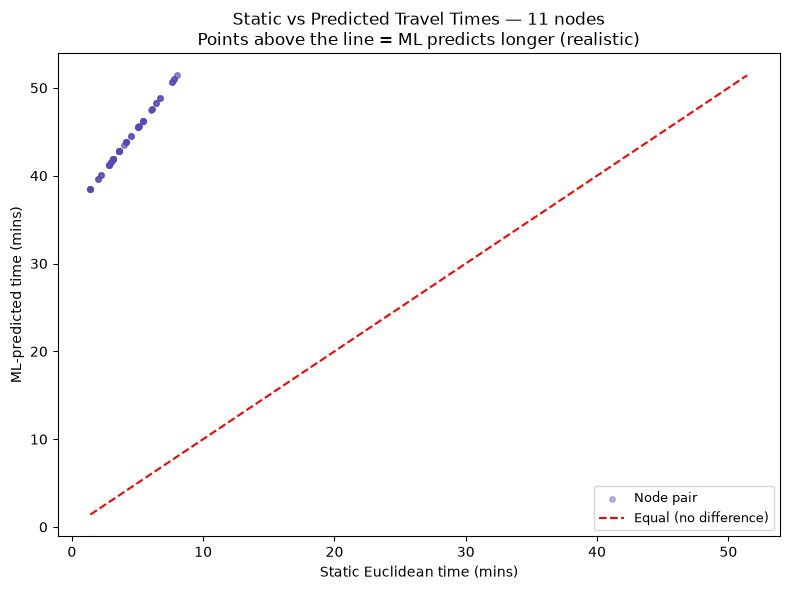

  Saved: ./predicted_matrix_11nodes_morning_rush_clear.png


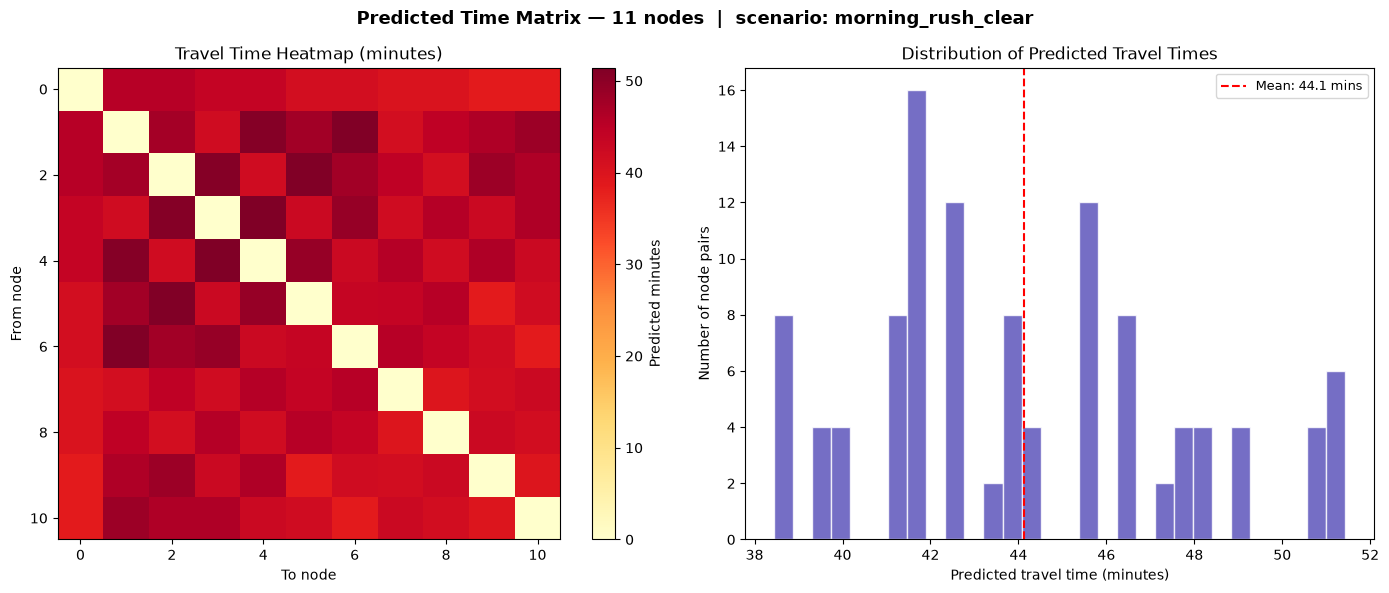

  Saved (integer): ./predicted_time_matrix_11nodes_LR_morning_rush_clear.csv
  Saved (float)  : ./predicted_time_matrix_11nodes_LR_morning_rush_clear_float.csv

  Scenario: morning_rush_fog
    {'time_of_day': 9, 'traffic_factor': 1.6, 'road_type': 1, 'vehicle_load_pct': 0.8, 'weather_condition': 2}

  Matrix preview (first 4×4 of 11×11):
    ['0.0', '26.2', '26.2', '24.5']
    ['26.2', '0.0', '28.2', '22.6']
    ['26.2', '28.2', '0.0', '31.4']
    ['24.5', '22.6', '31.4', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 4.30 mins
  Predicted mean  : 24.85 mins
  Mean difference : 20.55 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: 24.15 mins
  Max under-predict:17.74 mins
  Saved: ./static_vs_predicted_11nodes.png


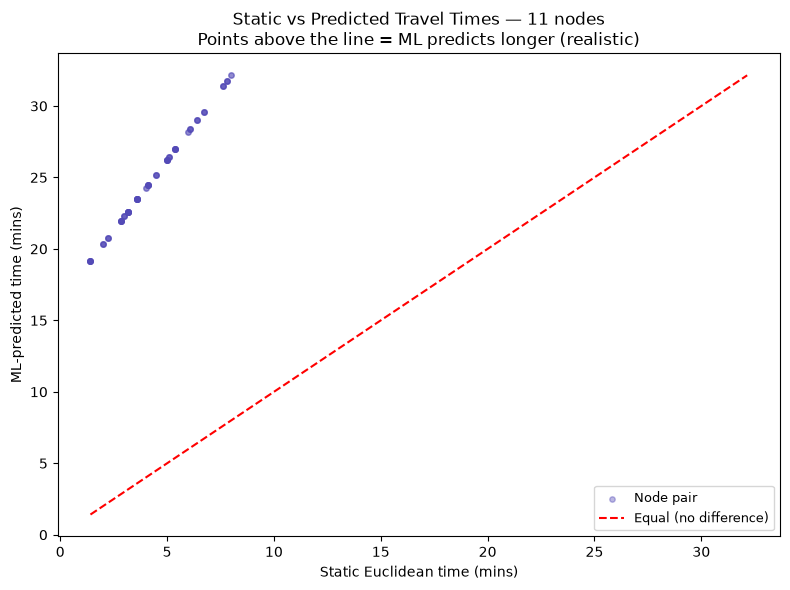

  Saved: ./predicted_matrix_11nodes_morning_rush_fog.png


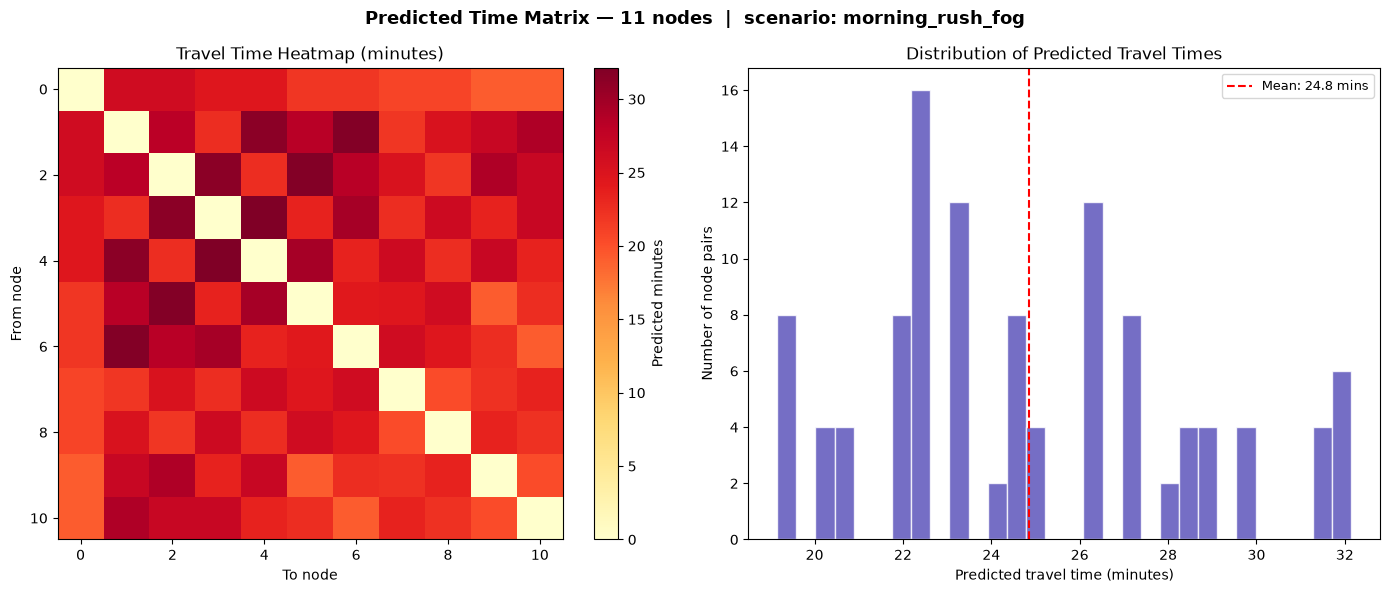

  Saved (integer): ./predicted_time_matrix_11nodes_LR_morning_rush_fog.csv
  Saved (float)  : ./predicted_time_matrix_11nodes_LR_morning_rush_fog_float.csv

  Scenario: morning_rush_rain
    {'time_of_day': 8, 'traffic_factor': 1.8, 'road_type': 0, 'vehicle_load_pct': 0.6, 'weather_condition': 1}

  Matrix preview (first 4×4 of 11×11):
    ['0.0', '56.0', '56.0', '54.3']
    ['56.0', '0.0', '58.0', '52.4']
    ['56.0', '58.0', '0.0', '61.2']
    ['54.3', '52.4', '61.2', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 4.30 mins
  Predicted mean  : 54.66 mins
  Mean difference : 50.36 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: 53.96 mins
  Max under-predict:47.55 mins
  Saved: ./static_vs_predicted_11nodes.png


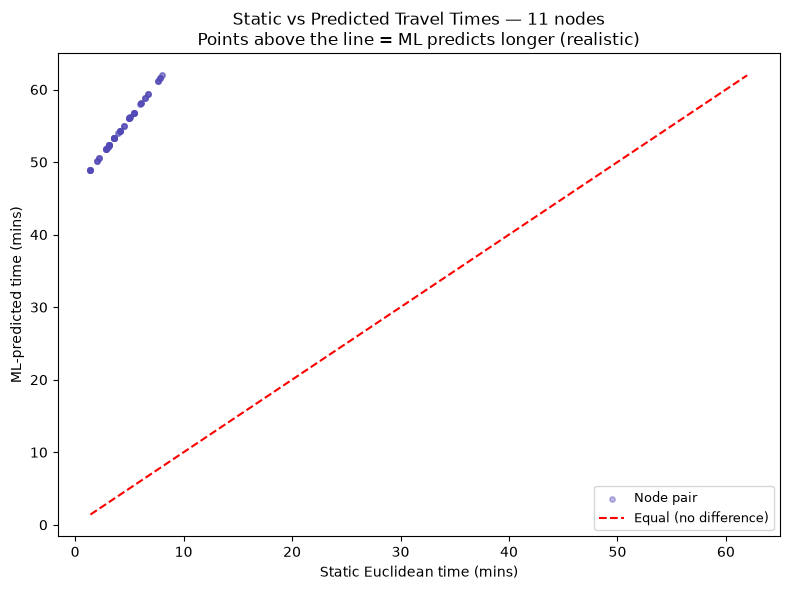

  Saved: ./predicted_matrix_11nodes_morning_rush_rain.png


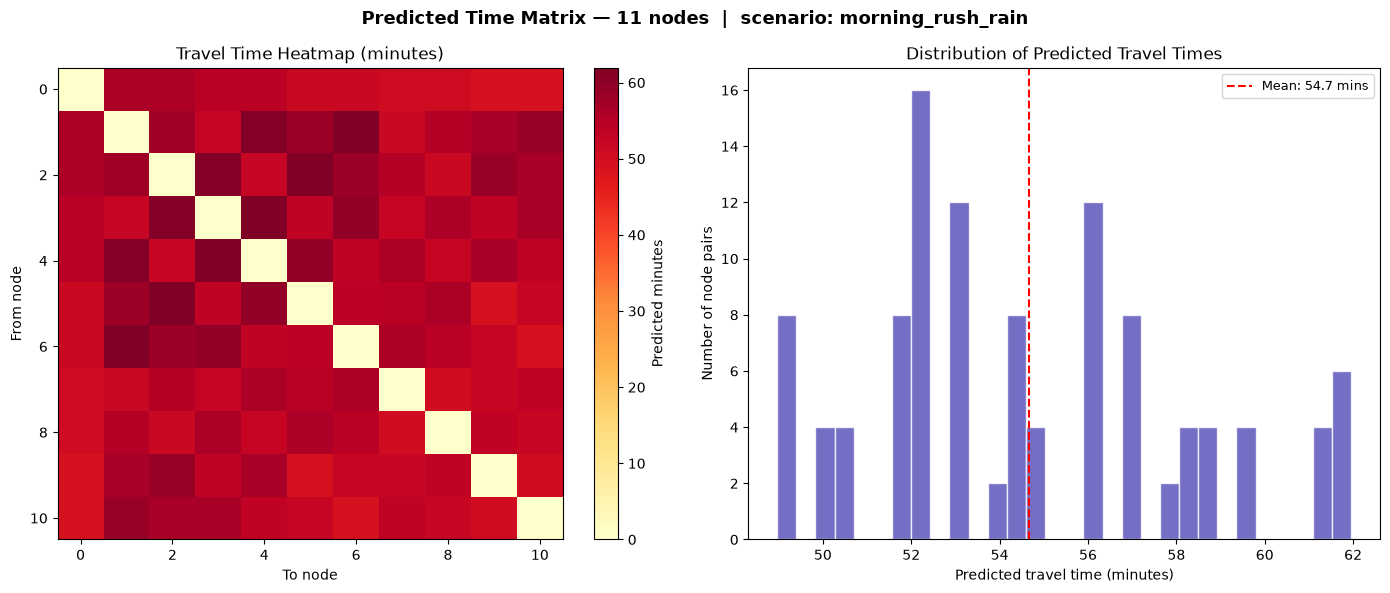

  Saved (integer): ./predicted_time_matrix_11nodes_LR_morning_rush_rain.csv
  Saved (float)  : ./predicted_time_matrix_11nodes_LR_morning_rush_rain_float.csv

  Scenario: midday_clear
    {'time_of_day': 12, 'traffic_factor': 1.1, 'road_type': 0, 'vehicle_load_pct': 0.5, 'weather_condition': 0}

  Matrix preview (first 4×4 of 11×11):
    ['0.0', '23.0', '23.0', '21.3']
    ['23.0', '0.0', '25.0', '19.4']
    ['23.0', '25.0', '0.0', '28.2']
    ['21.3', '19.4', '28.2', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 4.30 mins
  Predicted mean  : 21.64 mins
  Mean difference : 17.34 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: 20.94 mins
  Max under-predict:14.54 mins
  Saved: ./static_vs_predicted_11nodes.png


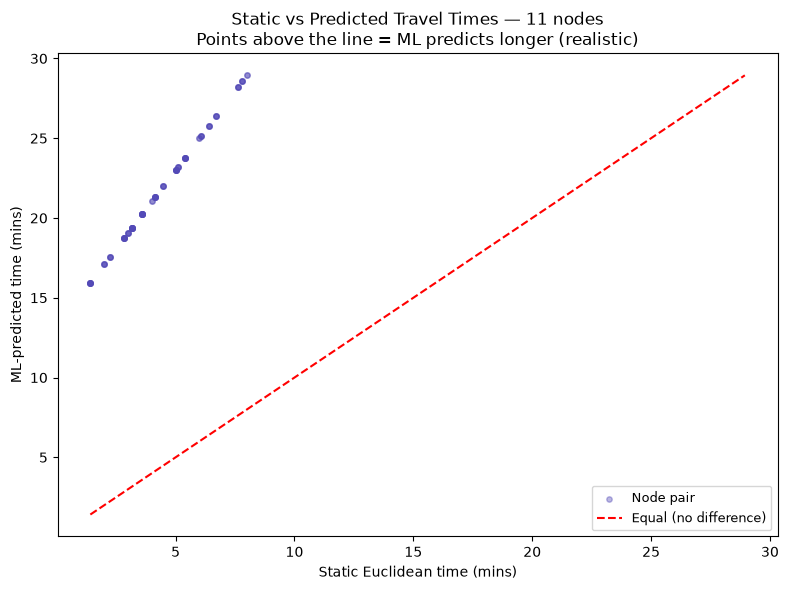

  Saved: ./predicted_matrix_11nodes_midday_clear.png


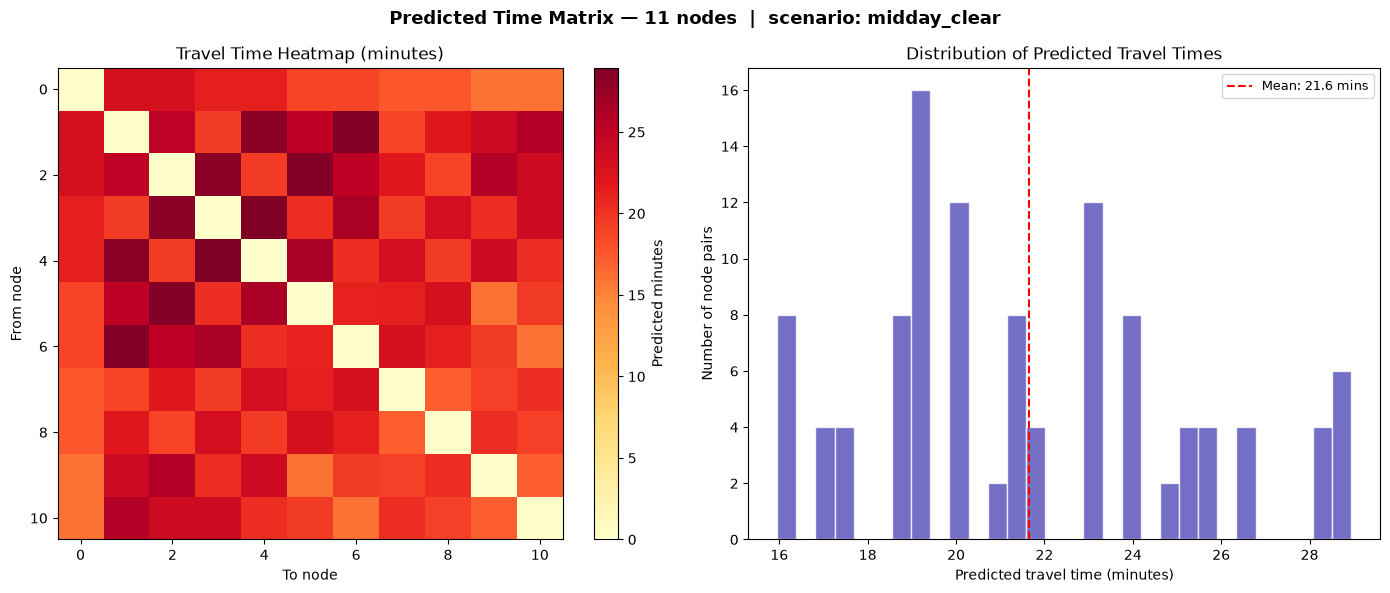

  Saved (integer): ./predicted_time_matrix_11nodes_LR_midday_clear.csv
  Saved (float)  : ./predicted_time_matrix_11nodes_LR_midday_clear_float.csv

  Scenario: midday_storm
    {'time_of_day': 14, 'traffic_factor': 1.4, 'road_type': 2, 'vehicle_load_pct': 0.7, 'weather_condition': 3}

  Matrix preview (first 4×4 of 11×11):
    ['0.0', '0.0', '0.0', '0.0']
    ['0.0', '0.0', '0.0', '0.0']
    ['0.0', '0.0', '0.0', '0.4']
    ['0.0', '0.0', '0.4', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 4.30 mins
  Predicted mean  : 0.07 mins
  Mean difference : -4.23 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: -1.41 mins
  Max under-predict:-7.18 mins
  Saved: ./static_vs_predicted_11nodes.png


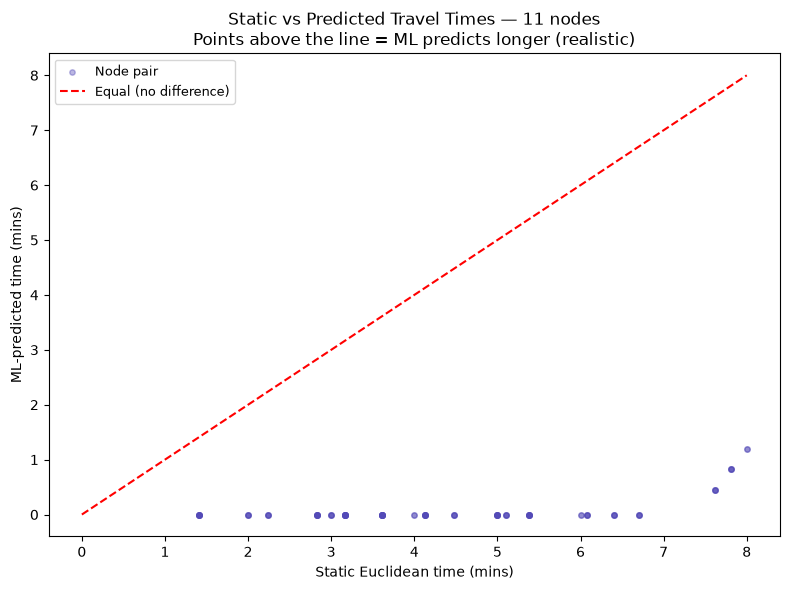

  Saved: ./predicted_matrix_11nodes_midday_storm.png


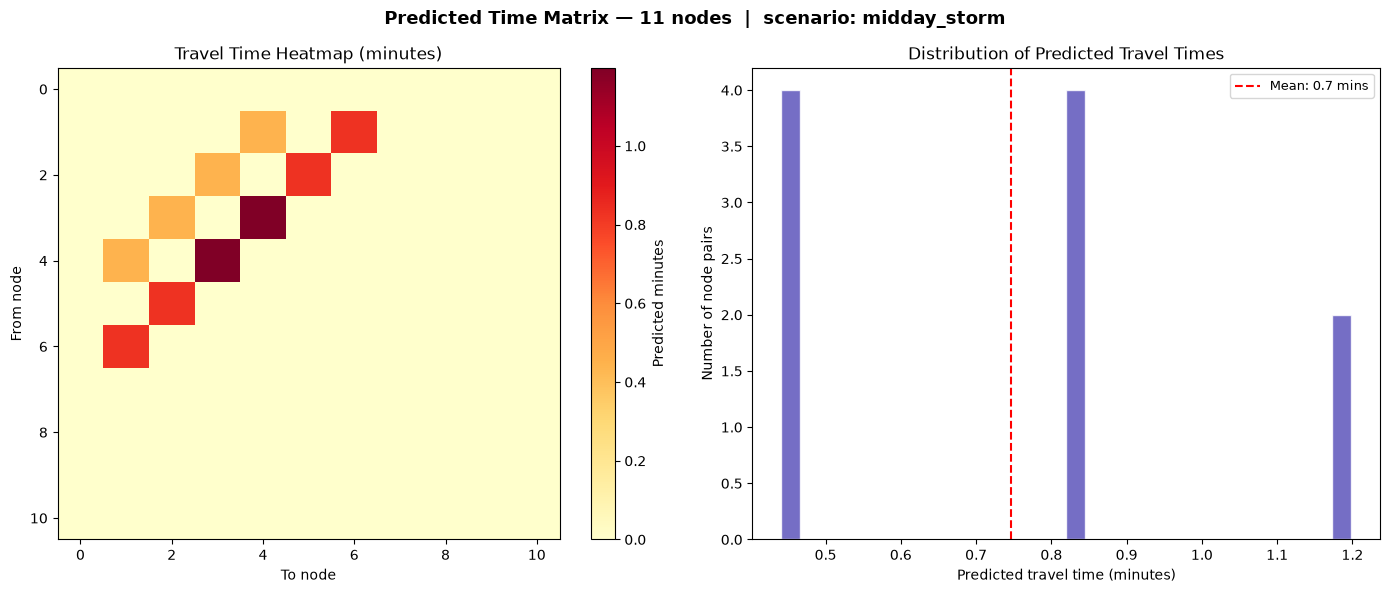

  Saved (integer): ./predicted_time_matrix_11nodes_LR_midday_storm.csv
  Saved (float)  : ./predicted_time_matrix_11nodes_LR_midday_storm_float.csv

  Scenario: evening_rush_fog
    {'time_of_day': 17, 'traffic_factor': 1.8, 'road_type': 2, 'vehicle_load_pct': 0.7, 'weather_condition': 2}

  Matrix preview (first 4×4 of 11×11):
    ['0.0', '1.7', '1.7', '0.0']
    ['1.7', '0.0', '3.7', '0.0']
    ['1.7', '3.7', '0.0', '6.9']
    ['0.0', '0.0', '6.9', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 4.30 mins
  Predicted mean  : 1.61 mins
  Mean difference : -2.69 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: -0.36 mins
  Max under-predict:-4.12 mins
  Saved: ./static_vs_predicted_11nodes.png


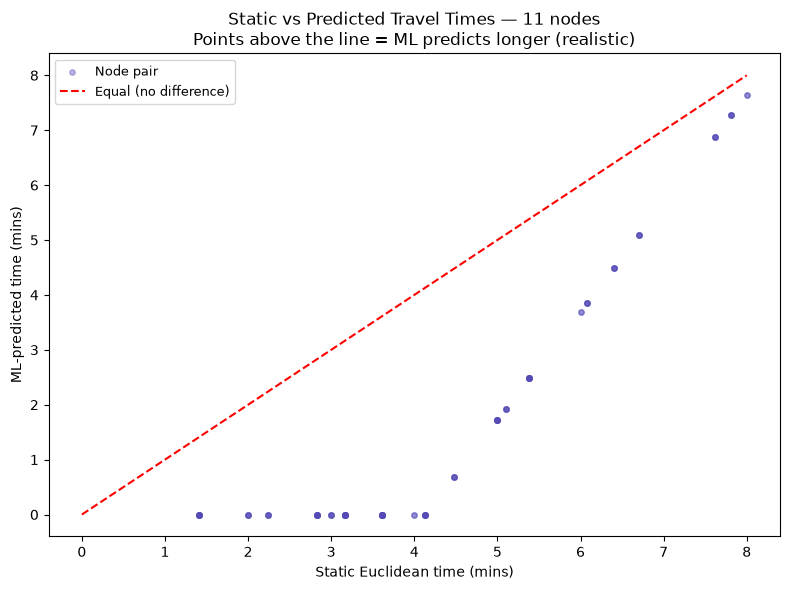

  Saved: ./predicted_matrix_11nodes_evening_rush_fog.png


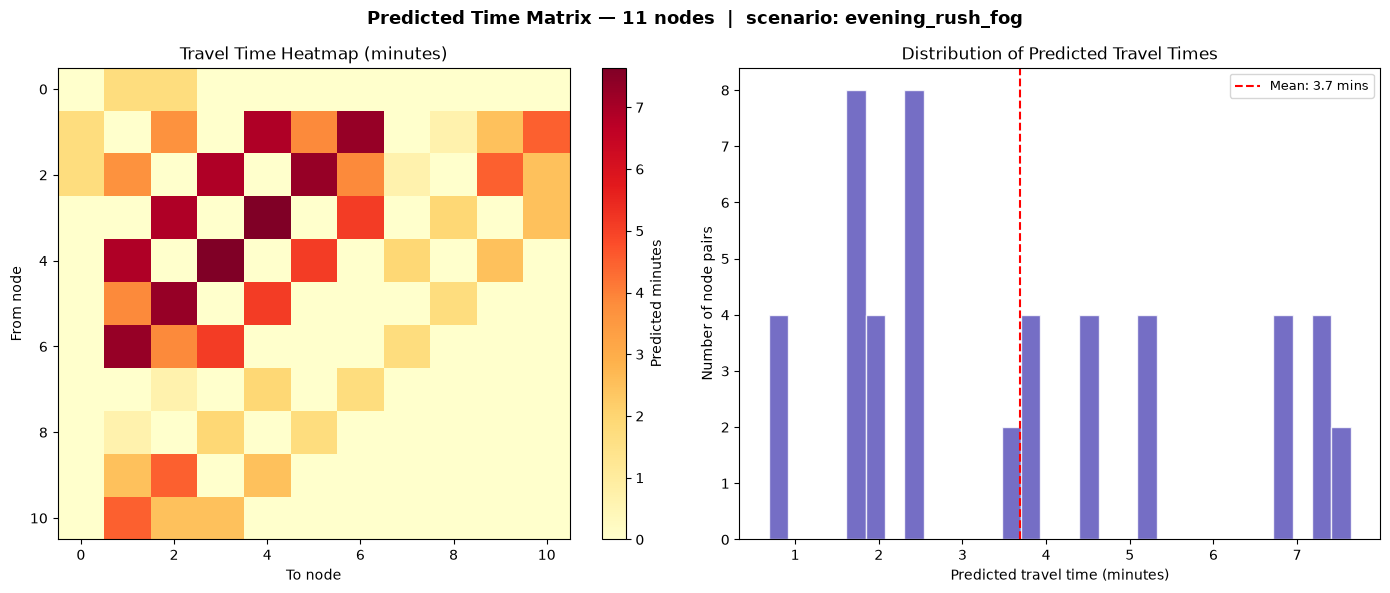

  Saved (integer): ./predicted_time_matrix_11nodes_LR_evening_rush_fog.csv
  Saved (float)  : ./predicted_time_matrix_11nodes_LR_evening_rush_fog_float.csv

  Scenario: evening_rush_storm
    {'time_of_day': 17, 'traffic_factor': 1.8, 'road_type': 2, 'vehicle_load_pct': 1, 'weather_condition': 3}

  Matrix preview (first 4×4 of 11×11):
    ['0.0', '8.7', '8.7', '7.0']
    ['8.7', '0.0', '10.7', '5.1']
    ['8.7', '10.7', '0.0', '13.9']
    ['7.0', '5.1', '13.9', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 4.30 mins
  Predicted mean  : 7.32 mins
  Mean difference : 3.02 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: 6.62 mins
  Max under-predict:0.22 mins
  Saved: ./static_vs_predicted_11nodes.png


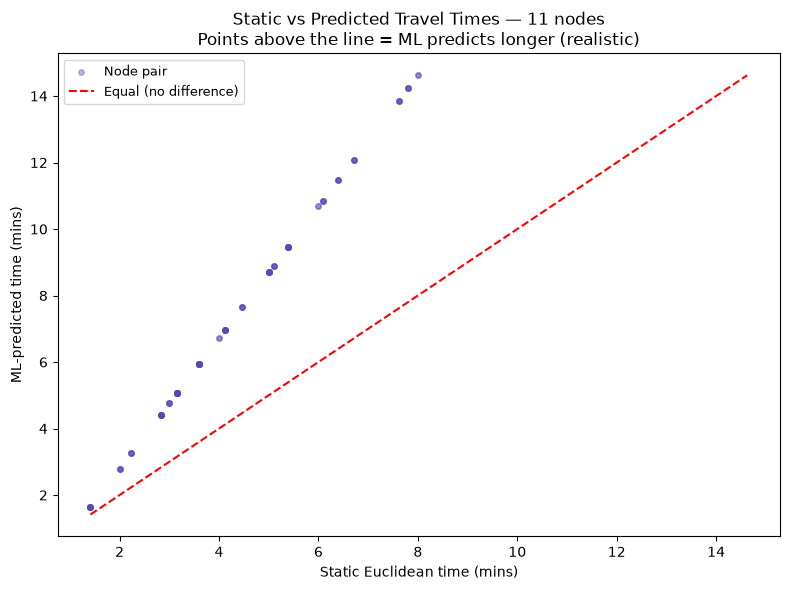

  Saved: ./predicted_matrix_11nodes_evening_rush_storm.png


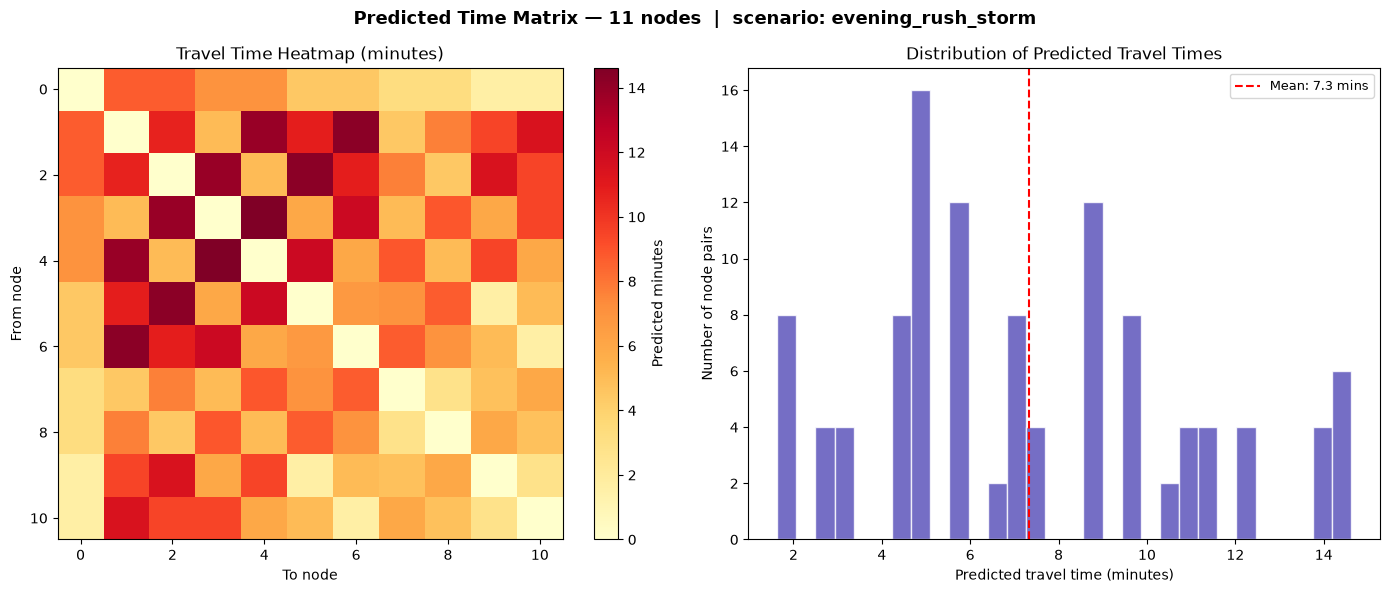

  Saved (integer): ./predicted_time_matrix_11nodes_LR_evening_rush_storm.csv
  Saved (float)  : ./predicted_time_matrix_11nodes_LR_evening_rush_storm_float.csv

  Problem size: 25 nodes
  Model loaded: linear_model_25.pkl
  Scaler loaded: linear_model_25_scaler.pkl

  Scenario: morning_rush_clear
    {'time_of_day': 8, 'traffic_factor': 1.7, 'road_type': 0, 'vehicle_load_pct': 0.6, 'weather_condition': 0}

  Matrix preview (first 4×4 of 25×25):
    ['0.0', '44.1', '44.1', '42.3']
    ['44.1', '0.0', '46.1', '40.4']
    ['44.1', '46.1', '0.0', '49.3']
    ['42.3', '40.4', '49.3', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 5.05 mins
  Predicted mean  : 44.17 mins
  Mean difference : 39.12 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: 44.65 mins
  Max under-predict:35.09 mins
  Saved: ./static_vs_predicted_25nodes.png


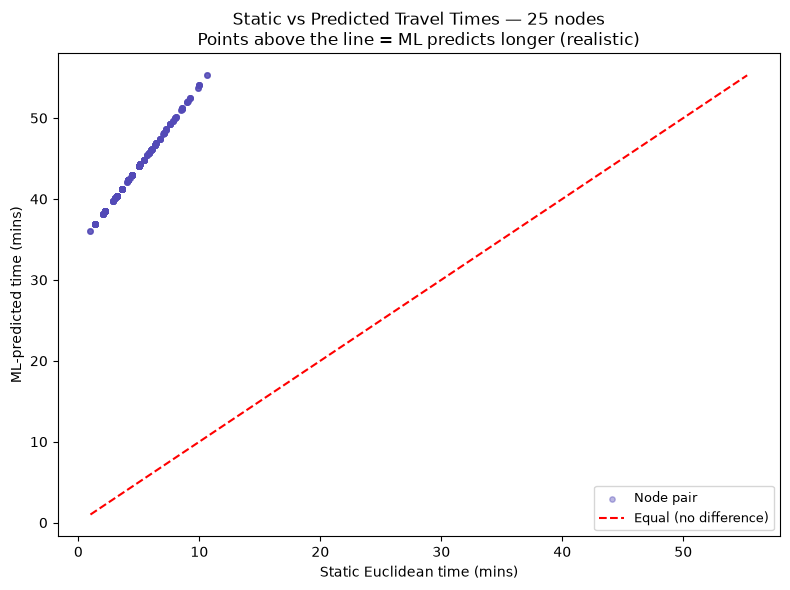

  Saved: ./predicted_matrix_25nodes_morning_rush_clear.png


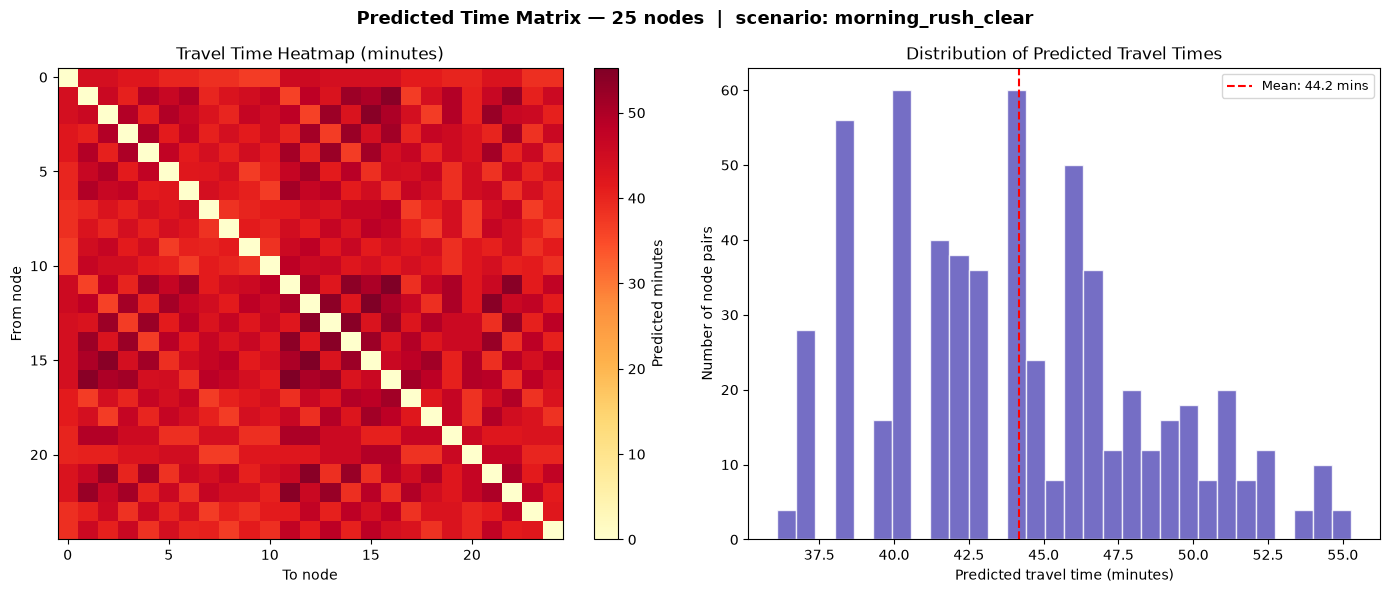

  Saved (integer): ./predicted_time_matrix_25nodes_LR_morning_rush_clear.csv
  Saved (float)  : ./predicted_time_matrix_25nodes_LR_morning_rush_clear_float.csv

  Scenario: morning_rush_fog
    {'time_of_day': 9, 'traffic_factor': 1.6, 'road_type': 1, 'vehicle_load_pct': 0.8, 'weather_condition': 2}

  Matrix preview (first 4×4 of 25×25):
    ['0.0', '27.1', '27.1', '25.3']
    ['27.1', '0.0', '29.1', '23.4']
    ['27.1', '29.1', '0.0', '32.3']
    ['25.3', '23.4', '32.3', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 5.05 mins
  Predicted mean  : 27.20 mins
  Mean difference : 22.15 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: 27.68 mins
  Max under-predict:18.12 mins
  Saved: ./static_vs_predicted_25nodes.png


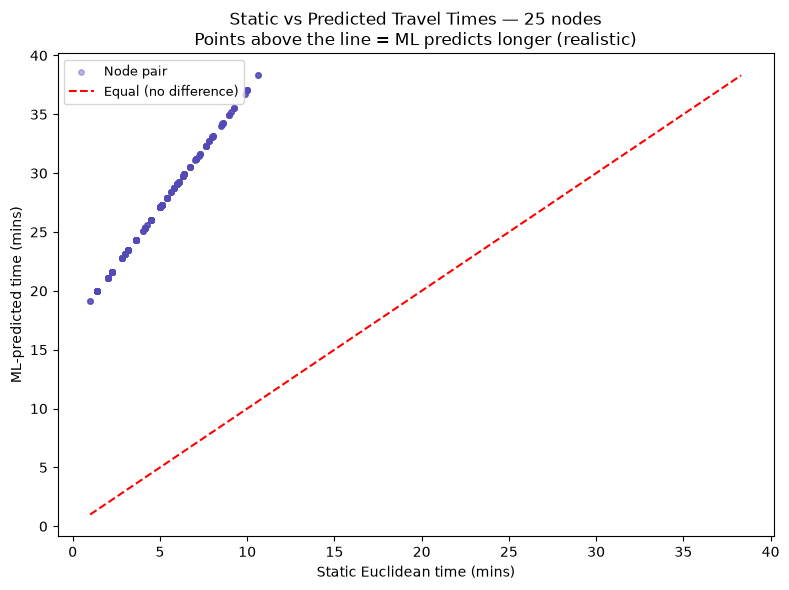

  Saved: ./predicted_matrix_25nodes_morning_rush_fog.png


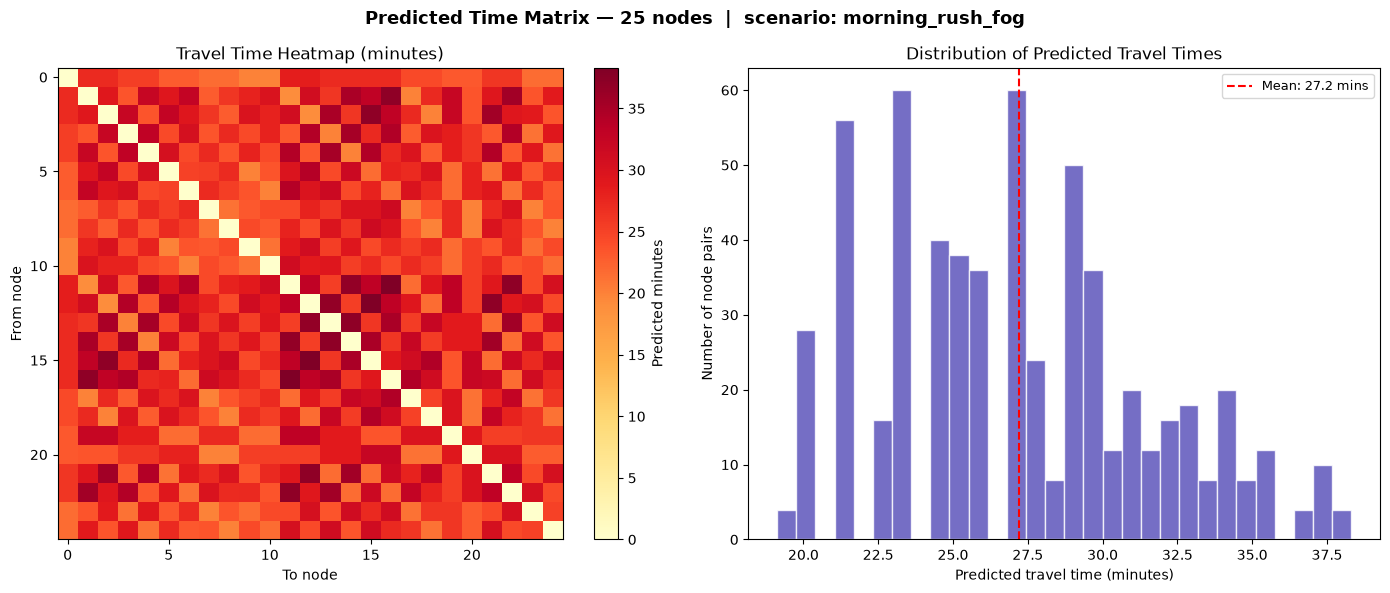

  Saved (integer): ./predicted_time_matrix_25nodes_LR_morning_rush_fog.csv
  Saved (float)  : ./predicted_time_matrix_25nodes_LR_morning_rush_fog_float.csv

  Scenario: morning_rush_rain
    {'time_of_day': 8, 'traffic_factor': 1.8, 'road_type': 0, 'vehicle_load_pct': 0.6, 'weather_condition': 1}

  Matrix preview (first 4×4 of 25×25):
    ['0.0', '55.3', '55.3', '53.6']
    ['55.3', '0.0', '57.3', '51.7']
    ['55.3', '57.3', '0.0', '60.5']
    ['53.6', '51.7', '60.5', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 5.05 mins
  Predicted mean  : 55.42 mins
  Mean difference : 50.37 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: 55.90 mins
  Max under-predict:46.34 mins
  Saved: ./static_vs_predicted_25nodes.png


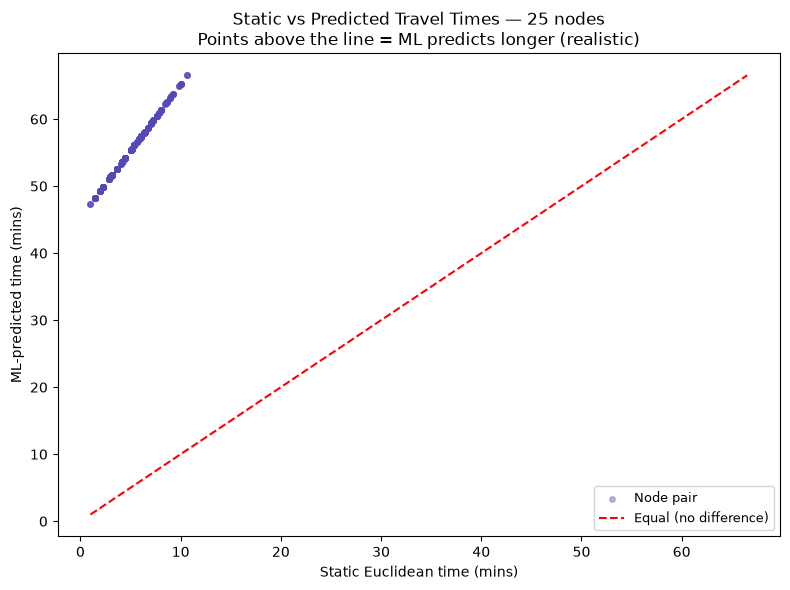

  Saved: ./predicted_matrix_25nodes_morning_rush_rain.png


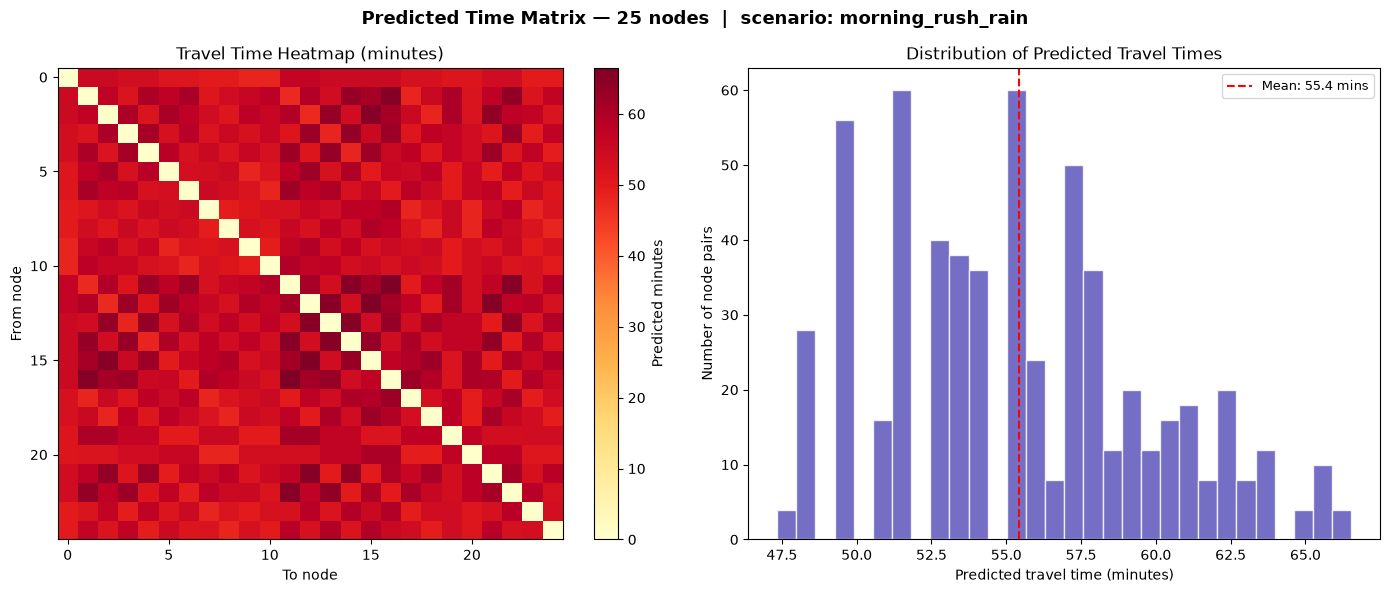

  Saved (integer): ./predicted_time_matrix_25nodes_LR_morning_rush_rain.csv
  Saved (float)  : ./predicted_time_matrix_25nodes_LR_morning_rush_rain_float.csv

  Scenario: midday_clear
    {'time_of_day': 12, 'traffic_factor': 1.1, 'road_type': 0, 'vehicle_load_pct': 0.5, 'weather_condition': 0}

  Matrix preview (first 4×4 of 25×25):
    ['0.0', '22.1', '22.1', '20.4']
    ['22.1', '0.0', '24.1', '18.4']
    ['22.1', '24.1', '0.0', '27.3']
    ['20.4', '18.4', '27.3', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 5.05 mins
  Predicted mean  : 22.22 mins
  Mean difference : 17.16 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: 22.70 mins
  Max under-predict:13.14 mins
  Saved: ./static_vs_predicted_25nodes.png


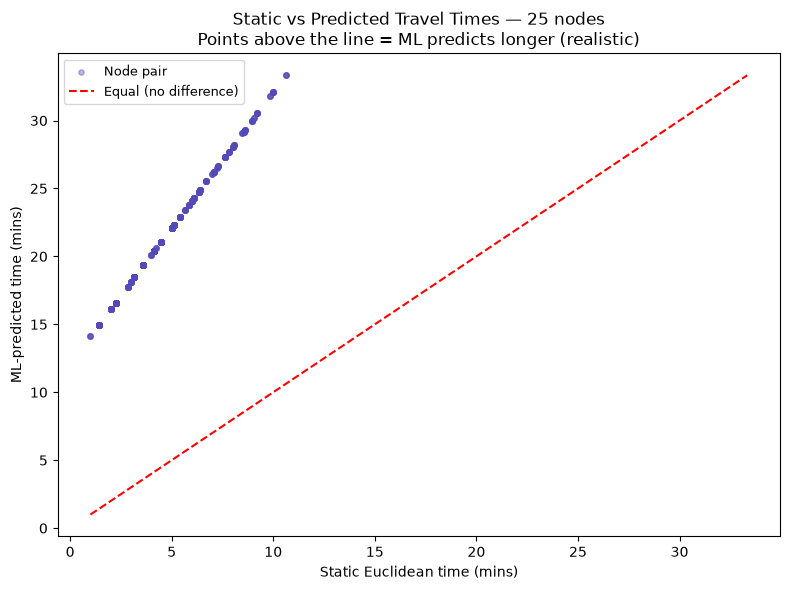

  Saved: ./predicted_matrix_25nodes_midday_clear.png


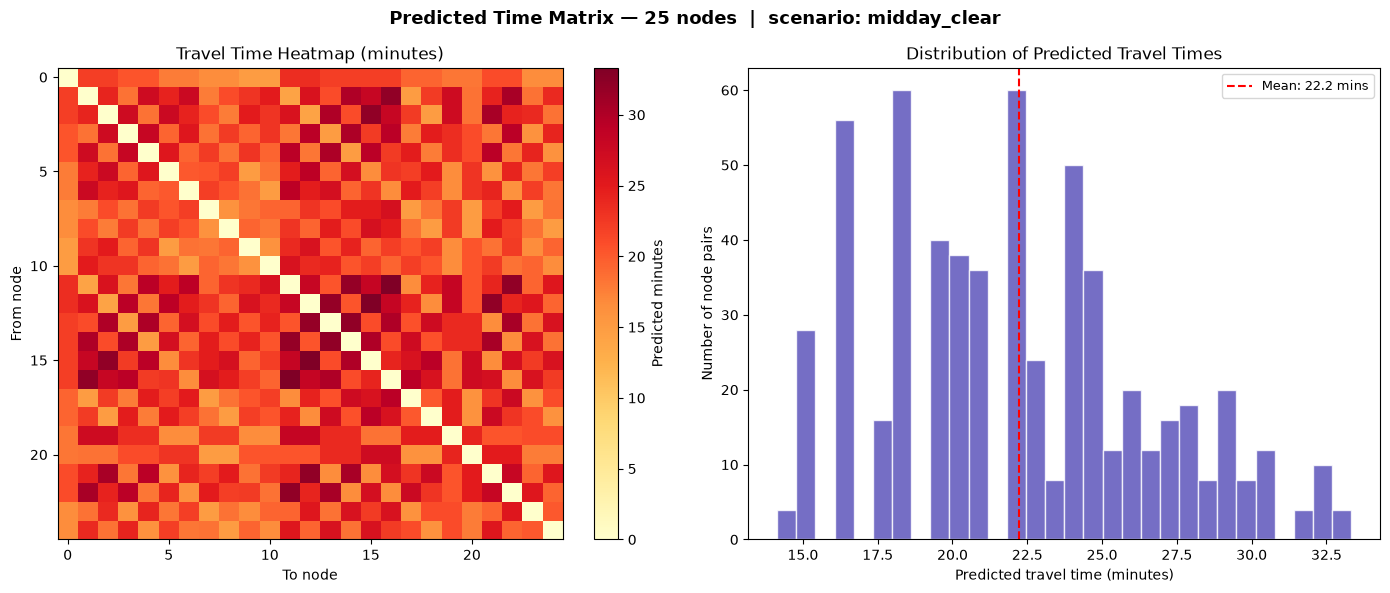

  Saved (integer): ./predicted_time_matrix_25nodes_LR_midday_clear.csv
  Saved (float)  : ./predicted_time_matrix_25nodes_LR_midday_clear_float.csv

  Scenario: midday_storm
    {'time_of_day': 14, 'traffic_factor': 1.4, 'road_type': 2, 'vehicle_load_pct': 0.7, 'weather_condition': 3}

  Matrix preview (first 4×4 of 25×25):
    ['0.0', '0.0', '0.0', '0.0']
    ['0.0', '0.0', '1.0', '0.0']
    ['0.0', '1.0', '0.0', '4.2']
    ['0.0', '0.0', '4.2', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 5.05 mins
  Predicted mean  : 1.45 mins
  Mean difference : -3.61 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: -0.41 mins
  Max under-predict:-5.39 mins
  Saved: ./static_vs_predicted_25nodes.png


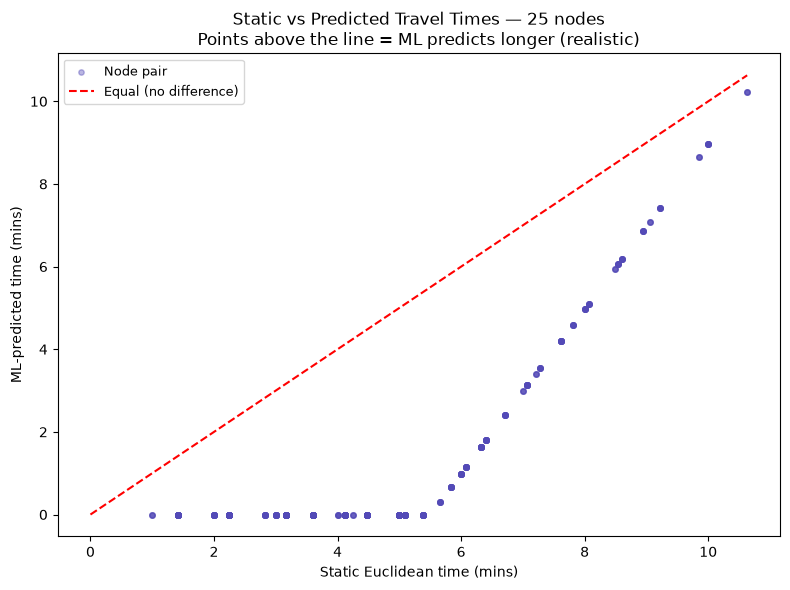

  Saved: ./predicted_matrix_25nodes_midday_storm.png


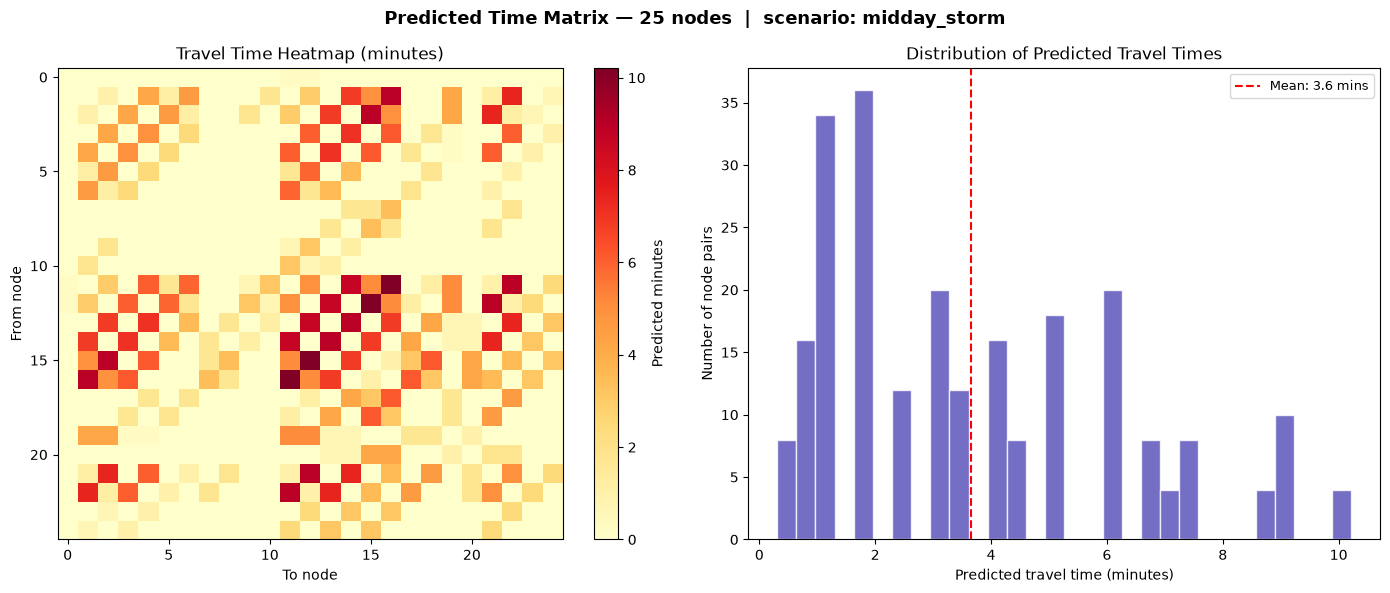

  Saved (integer): ./predicted_time_matrix_25nodes_LR_midday_storm.csv
  Saved (float)  : ./predicted_time_matrix_25nodes_LR_midday_storm_float.csv

  Scenario: evening_rush_fog
    {'time_of_day': 17, 'traffic_factor': 1.8, 'road_type': 2, 'vehicle_load_pct': 0.7, 'weather_condition': 2}

  Matrix preview (first 4×4 of 25×25):
    ['0.0', '6.3', '6.3', '4.5']
    ['6.3', '0.0', '8.3', '2.6']
    ['6.3', '8.3', '0.0', '11.5']
    ['4.5', '2.6', '11.5', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 5.05 mins
  Predicted mean  : 6.42 mins
  Mean difference : 1.37 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: 6.85 mins
  Max under-predict:-1.72 mins
  Saved: ./static_vs_predicted_25nodes.png


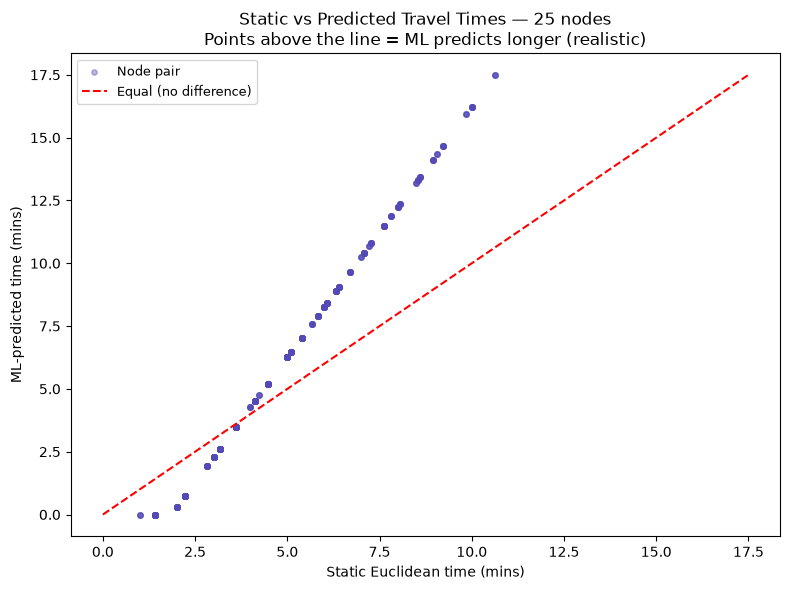

  Saved: ./predicted_matrix_25nodes_evening_rush_fog.png


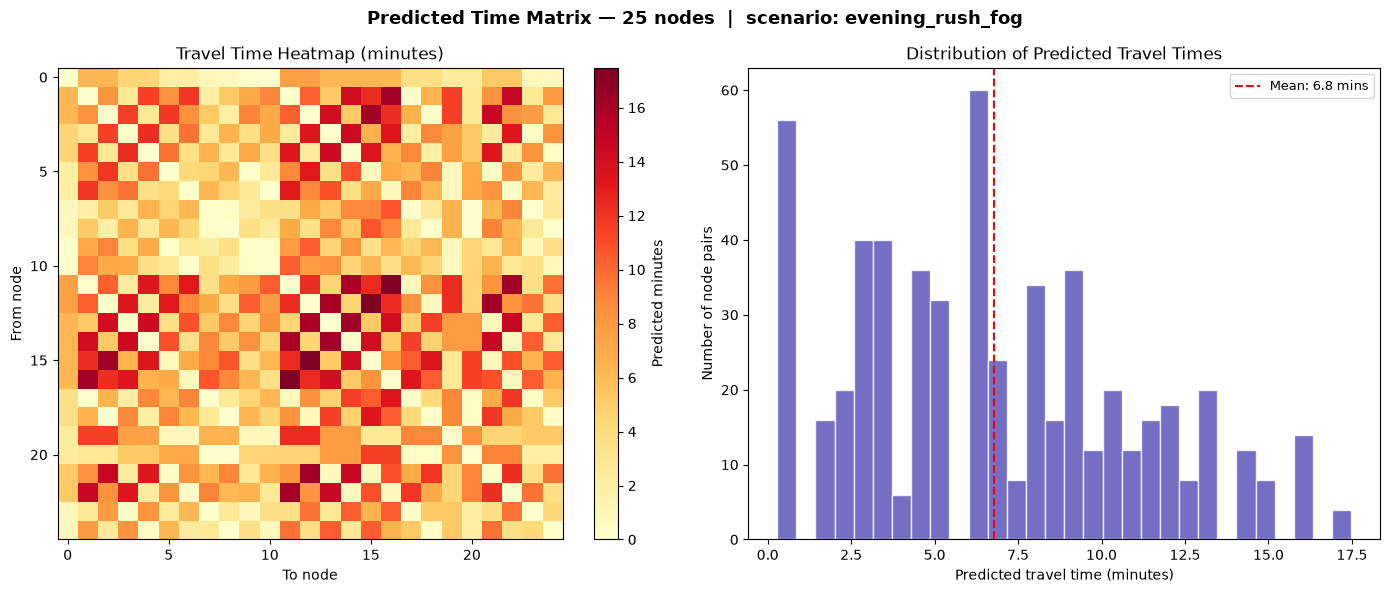

  Saved (integer): ./predicted_time_matrix_25nodes_LR_evening_rush_fog.csv
  Saved (float)  : ./predicted_time_matrix_25nodes_LR_evening_rush_fog_float.csv

  Scenario: evening_rush_storm
    {'time_of_day': 17, 'traffic_factor': 1.8, 'road_type': 2, 'vehicle_load_pct': 1, 'weather_condition': 3}

  Matrix preview (first 4×4 of 25×25):
    ['0.0', '13.8', '13.8', '12.1']
    ['13.8', '0.0', '15.8', '10.2']
    ['13.8', '15.8', '0.0', '19.1']
    ['12.1', '10.2', '19.1', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 5.05 mins
  Predicted mean  : 13.95 mins
  Mean difference : 8.90 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: 14.43 mins
  Max under-predict:4.87 mins
  Saved: ./static_vs_predicted_25nodes.png


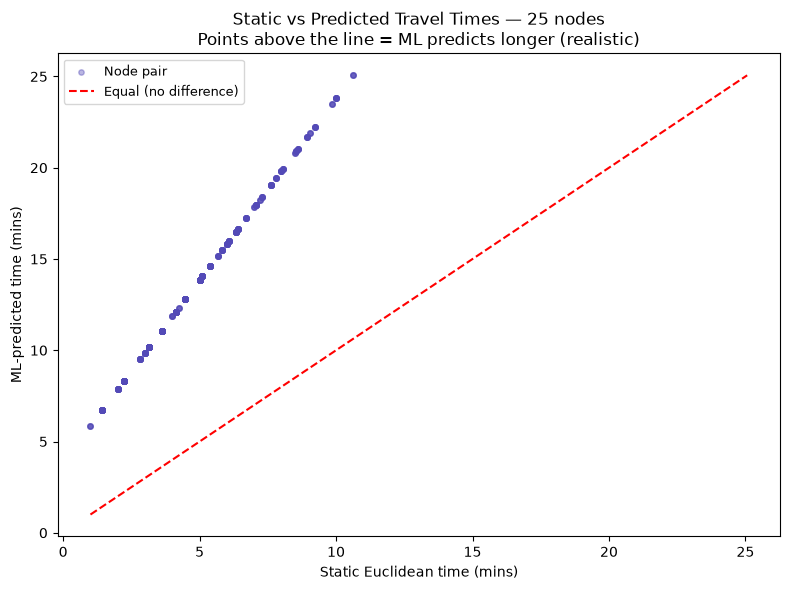

  Saved: ./predicted_matrix_25nodes_evening_rush_storm.png


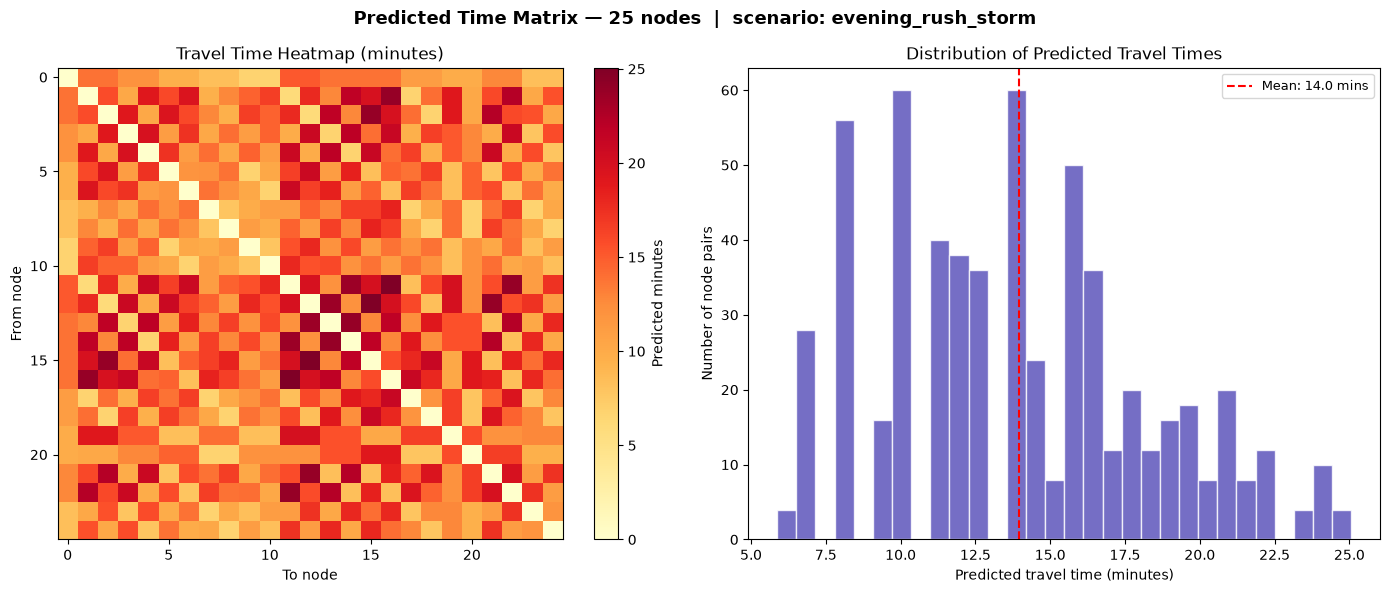

  Saved (integer): ./predicted_time_matrix_25nodes_LR_evening_rush_storm.csv
  Saved (float)  : ./predicted_time_matrix_25nodes_LR_evening_rush_storm_float.csv

  Problem size: 50 nodes
  Model loaded: linear_model_50.pkl
  Scaler loaded: linear_model_50_scaler.pkl

  Scenario: morning_rush_clear
    {'time_of_day': 8, 'traffic_factor': 1.7, 'road_type': 0, 'vehicle_load_pct': 0.6, 'weather_condition': 0}

  Matrix preview (first 4×4 of 50×50):
    ['0.0', '41.6', '41.6', '39.9']
    ['41.6', '0.0', '43.7', '37.9']
    ['41.6', '43.7', '0.0', '46.9']
    ['39.9', '37.9', '46.9', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 4.99 mins
  Predicted mean  : 41.62 mins
  Mean difference : 36.63 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: 43.44 mins
  Max under-predict:32.55 mins
  Saved: ./static_vs_predicted_50nodes.png


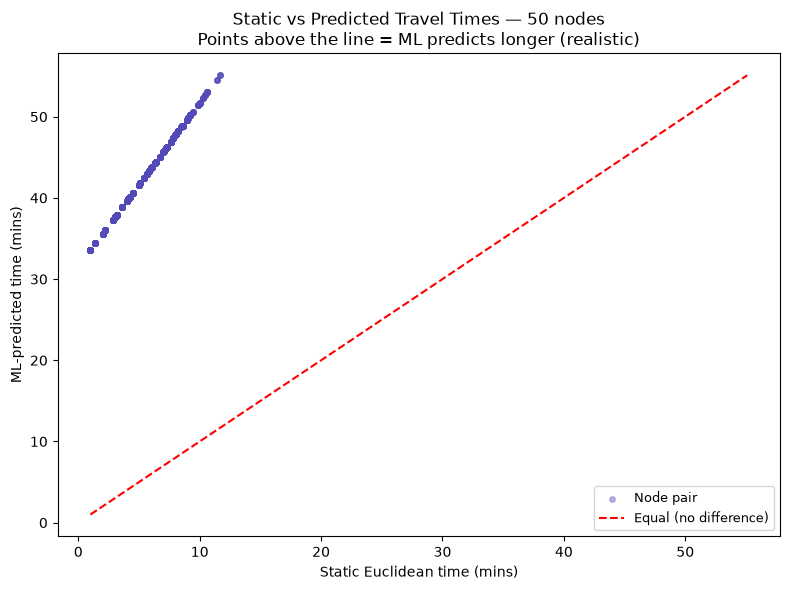

  Saved: ./predicted_matrix_50nodes_morning_rush_clear.png


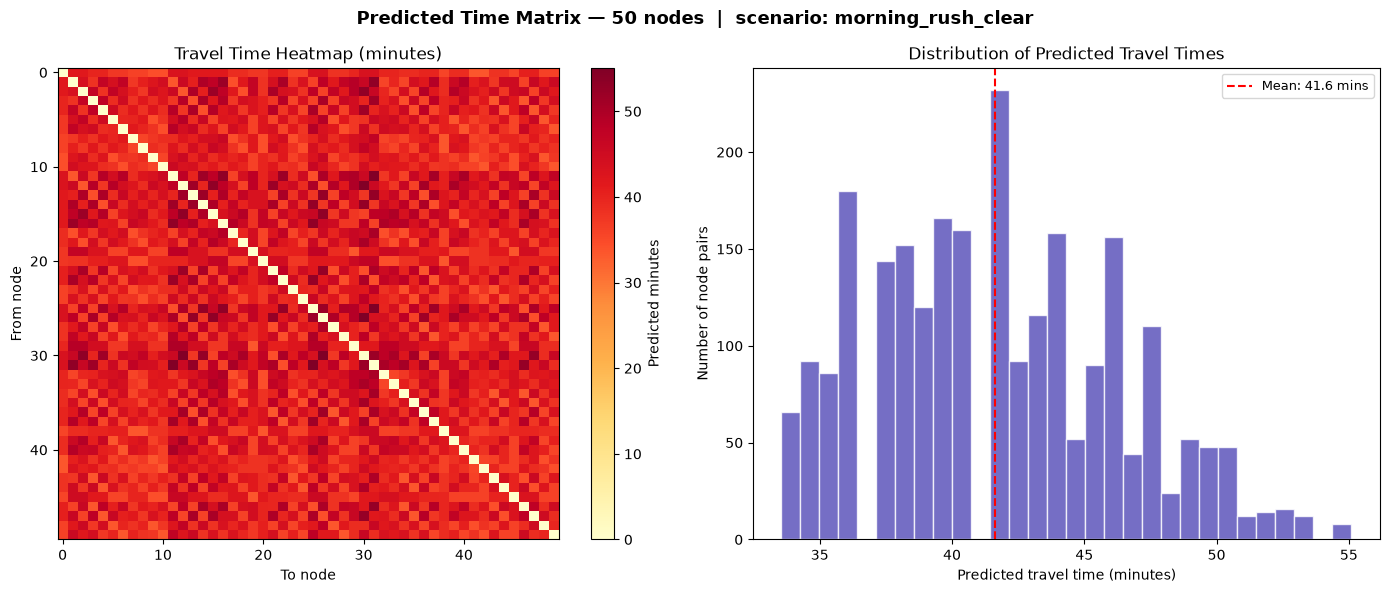

  Saved (integer): ./predicted_time_matrix_50nodes_LR_morning_rush_clear.csv
  Saved (float)  : ./predicted_time_matrix_50nodes_LR_morning_rush_clear_float.csv

  Scenario: morning_rush_fog
    {'time_of_day': 9, 'traffic_factor': 1.6, 'road_type': 1, 'vehicle_load_pct': 0.8, 'weather_condition': 2}

  Matrix preview (first 4×4 of 50×50):
    ['0.0', '24.4', '24.4', '22.7']
    ['24.4', '0.0', '26.5', '20.7']
    ['24.4', '26.5', '0.0', '29.7']
    ['22.7', '20.7', '29.7', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 4.99 mins
  Predicted mean  : 24.42 mins
  Mean difference : 19.43 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: 26.24 mins
  Max under-predict:15.35 mins
  Saved: ./static_vs_predicted_50nodes.png


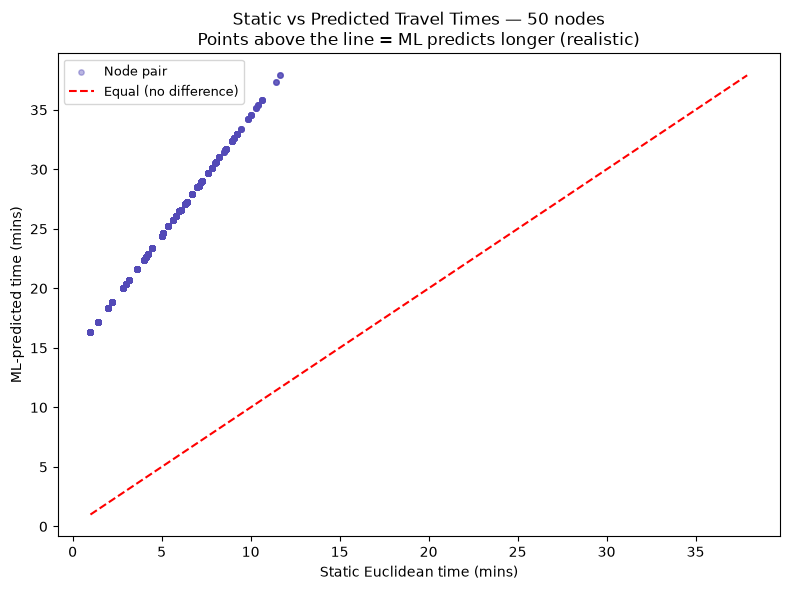

  Saved: ./predicted_matrix_50nodes_morning_rush_fog.png


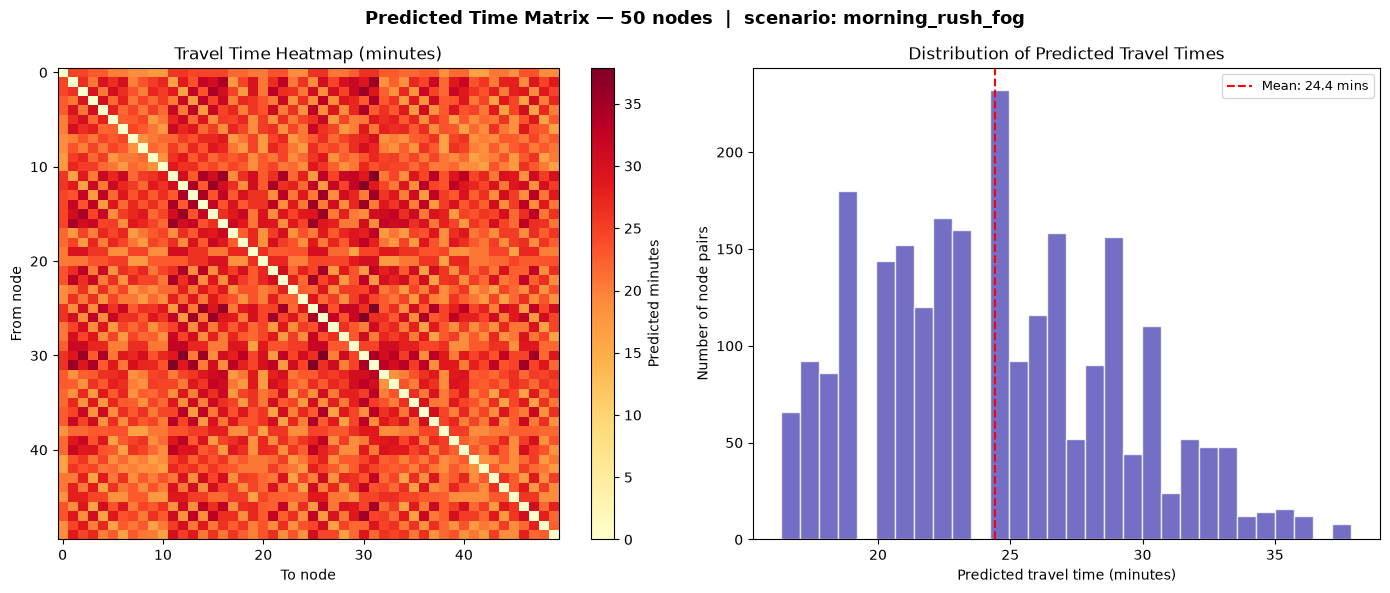

  Saved (integer): ./predicted_time_matrix_50nodes_LR_morning_rush_fog.csv
  Saved (float)  : ./predicted_time_matrix_50nodes_LR_morning_rush_fog_float.csv

  Scenario: morning_rush_rain
    {'time_of_day': 8, 'traffic_factor': 1.8, 'road_type': 0, 'vehicle_load_pct': 0.6, 'weather_condition': 1}

  Matrix preview (first 4×4 of 50×50):
    ['0.0', '52.5', '52.5', '50.8']
    ['52.5', '0.0', '54.6', '48.8']
    ['52.5', '54.6', '0.0', '57.8']
    ['50.8', '48.8', '57.8', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 4.99 mins
  Predicted mean  : 52.52 mins
  Mean difference : 47.53 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: 54.34 mins
  Max under-predict:43.46 mins
  Saved: ./static_vs_predicted_50nodes.png


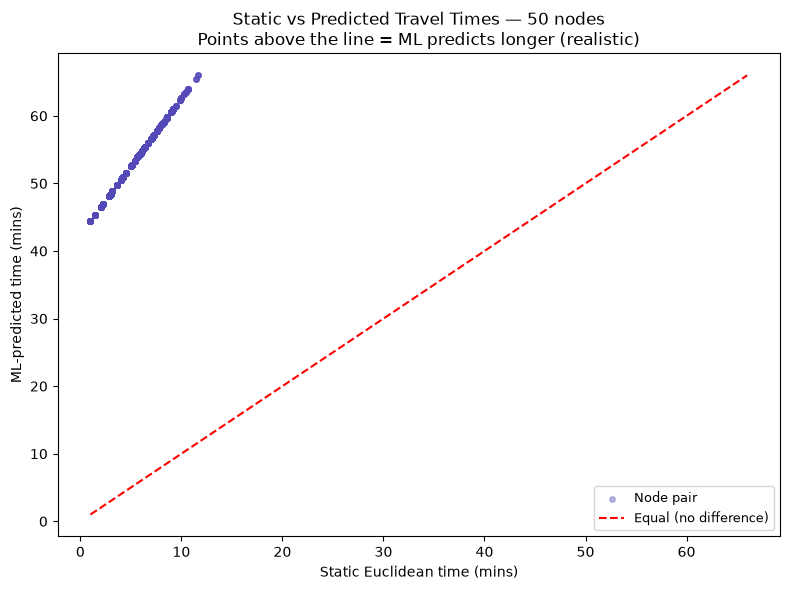

  Saved: ./predicted_matrix_50nodes_morning_rush_rain.png


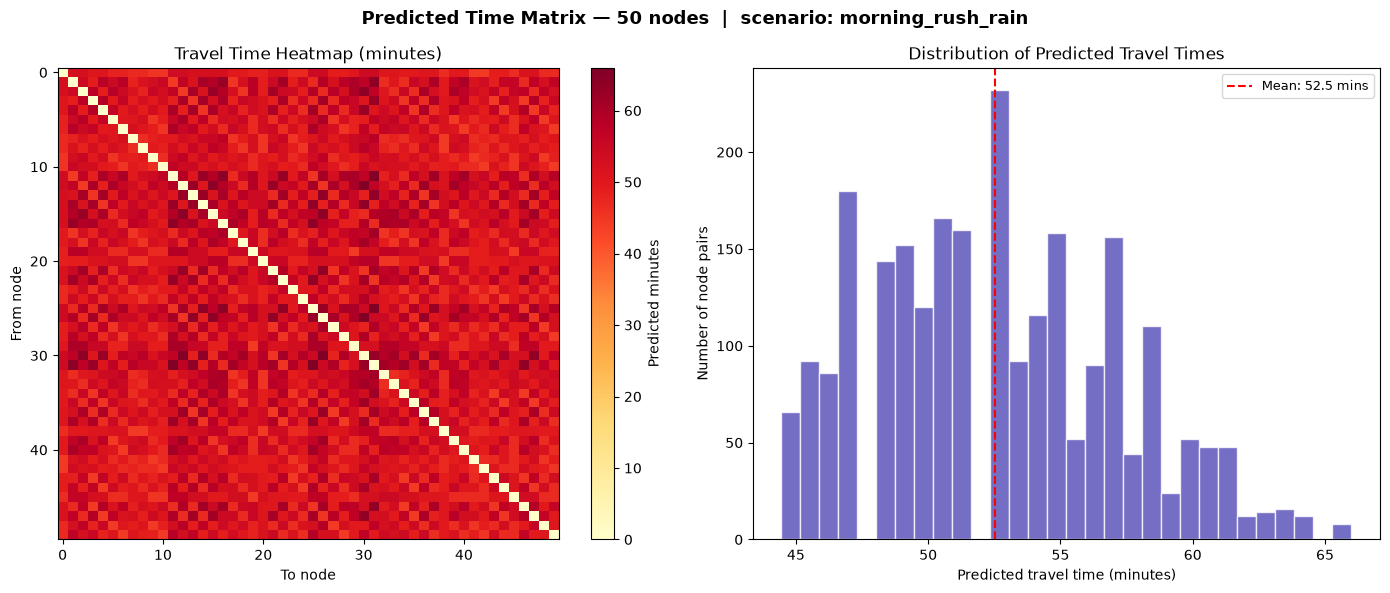

  Saved (integer): ./predicted_time_matrix_50nodes_LR_morning_rush_rain.csv
  Saved (float)  : ./predicted_time_matrix_50nodes_LR_morning_rush_rain_float.csv

  Scenario: midday_clear
    {'time_of_day': 12, 'traffic_factor': 1.1, 'road_type': 0, 'vehicle_load_pct': 0.5, 'weather_condition': 0}

  Matrix preview (first 4×4 of 50×50):
    ['0.0', '20.3', '20.3', '18.5']
    ['20.3', '0.0', '22.3', '16.6']
    ['20.3', '22.3', '0.0', '25.6']
    ['18.5', '16.6', '25.6', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 4.99 mins
  Predicted mean  : 20.26 mins
  Mean difference : 15.27 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: 22.09 mins
  Max under-predict:11.20 mins
  Saved: ./static_vs_predicted_50nodes.png


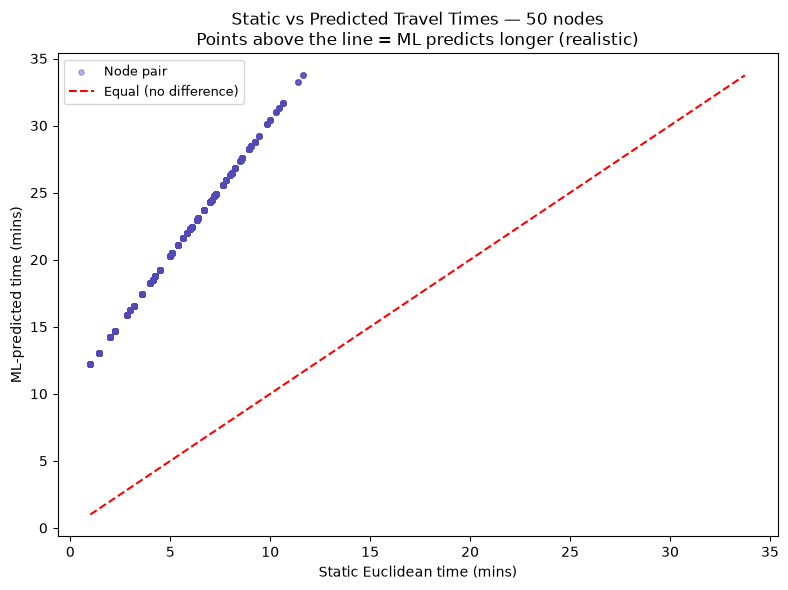

  Saved: ./predicted_matrix_50nodes_midday_clear.png


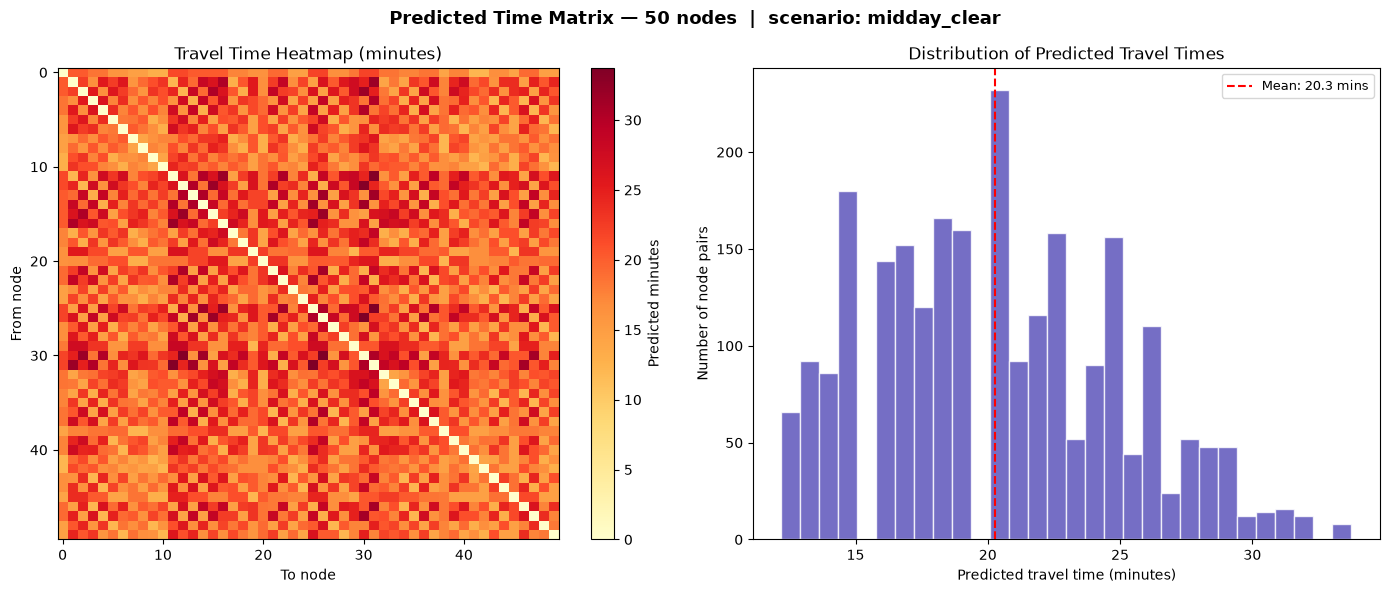

  Saved (integer): ./predicted_time_matrix_50nodes_LR_midday_clear.csv
  Saved (float)  : ./predicted_time_matrix_50nodes_LR_midday_clear_float.csv

  Scenario: midday_storm
    {'time_of_day': 14, 'traffic_factor': 1.4, 'road_type': 2, 'vehicle_load_pct': 0.7, 'weather_condition': 3}

  Matrix preview (first 4×4 of 50×50):
    ['0.0', '0.0', '0.0', '0.0']
    ['0.0', '0.0', '0.0', '0.0']
    ['0.0', '0.0', '0.0', '2.0']
    ['0.0', '0.0', '2.0', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 4.99 mins
  Predicted mean  : 0.73 mins
  Mean difference : -4.26 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: -1.00 mins
  Max under-predict:-6.58 mins
  Saved: ./static_vs_predicted_50nodes.png


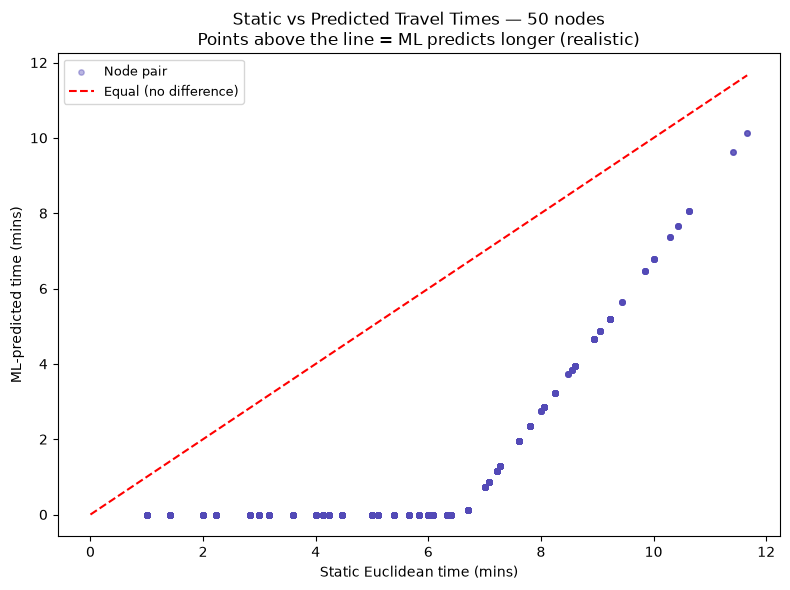

  Saved: ./predicted_matrix_50nodes_midday_storm.png


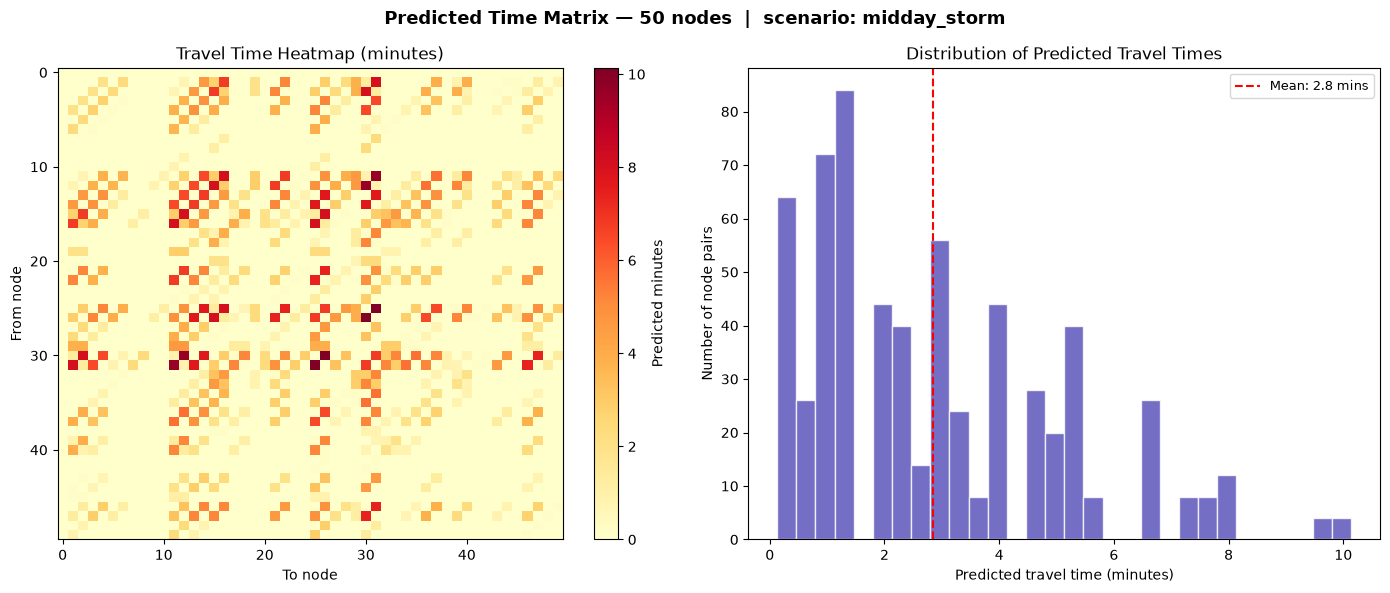

  Saved (integer): ./predicted_time_matrix_50nodes_LR_midday_storm.csv
  Saved (float)  : ./predicted_time_matrix_50nodes_LR_midday_storm_float.csv

  Scenario: evening_rush_fog
    {'time_of_day': 17, 'traffic_factor': 1.8, 'road_type': 2, 'vehicle_load_pct': 0.7, 'weather_condition': 2}

  Matrix preview (first 4×4 of 50×50):
    ['0.0', '4.1', '4.1', '2.4']
    ['4.1', '0.0', '6.2', '0.4']
    ['4.1', '6.2', '0.0', '9.4']
    ['2.4', '0.4', '9.4', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 4.99 mins
  Predicted mean  : 4.52 mins
  Mean difference : -0.47 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: 5.94 mins
  Max under-predict:-2.90 mins
  Saved: ./static_vs_predicted_50nodes.png


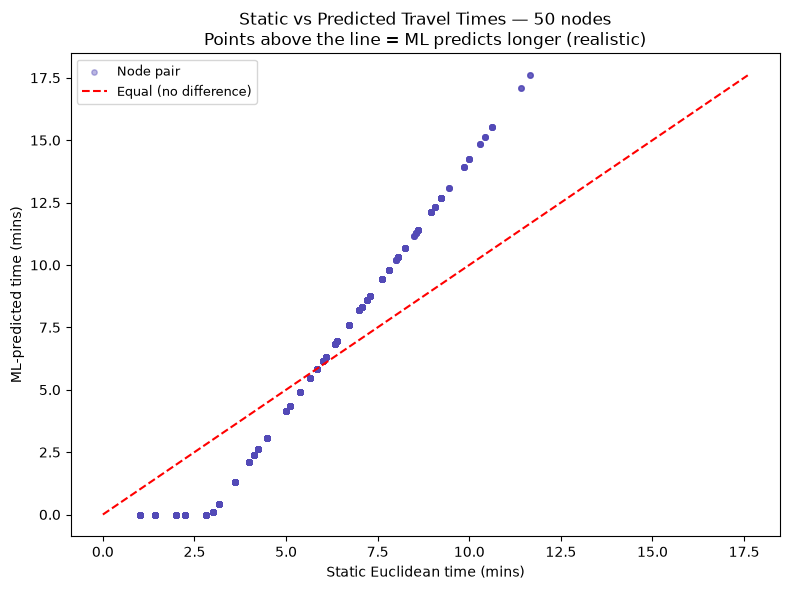

  Saved: ./predicted_matrix_50nodes_evening_rush_fog.png


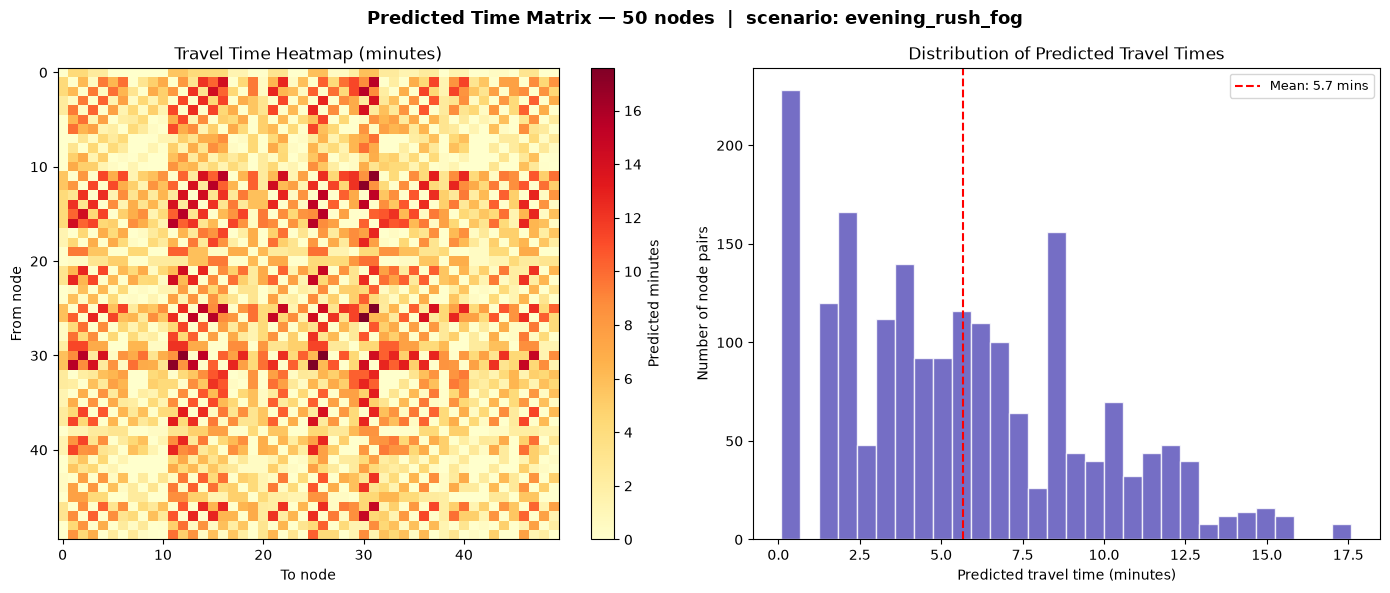

  Saved (integer): ./predicted_time_matrix_50nodes_LR_evening_rush_fog.csv
  Saved (float)  : ./predicted_time_matrix_50nodes_LR_evening_rush_fog_float.csv

  Scenario: evening_rush_storm
    {'time_of_day': 17, 'traffic_factor': 1.8, 'road_type': 2, 'vehicle_load_pct': 1, 'weather_condition': 3}

  Matrix preview (first 4×4 of 50×50):
    ['0.0', '11.4', '11.4', '9.7']
    ['11.4', '0.0', '13.5', '7.7']
    ['11.4', '13.5', '0.0', '16.7']
    ['9.7', '7.7', '16.7', '0.0']

  Comparison: Predicted vs Static Euclidean
  Static mean     : 4.99 mins
  Predicted mean  : 11.42 mins
  Mean difference : 6.43 mins  (+ve = predicted longer than Euclidean)
  Max over-predict: 13.24 mins
  Max under-predict:2.36 mins
  Saved: ./static_vs_predicted_50nodes.png


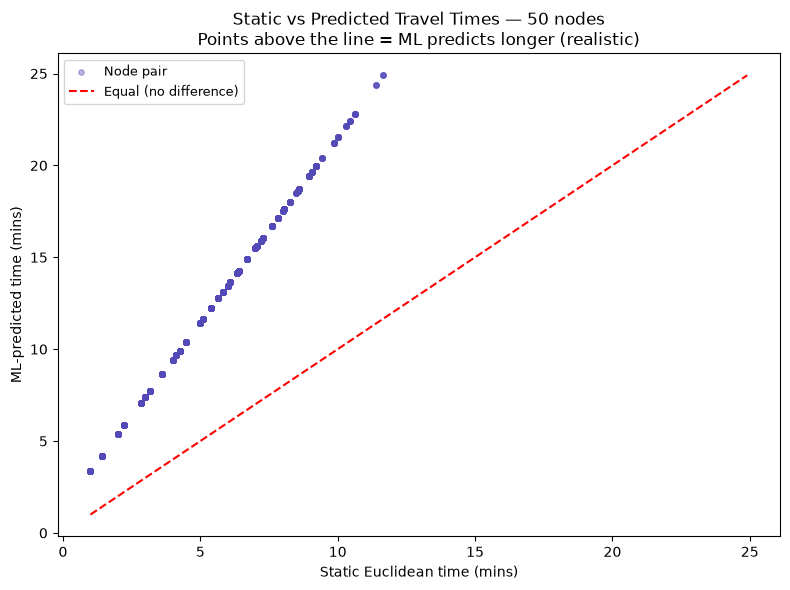

  Saved: ./predicted_matrix_50nodes_evening_rush_storm.png


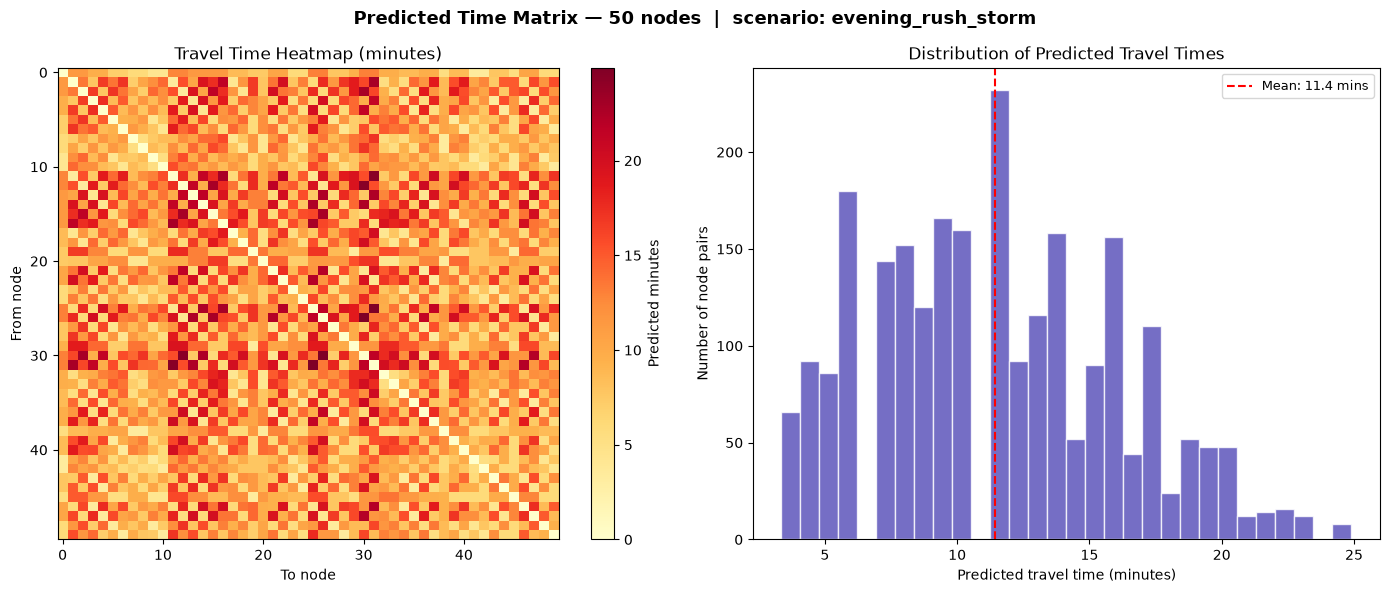

  Saved (integer): ./predicted_time_matrix_50nodes_LR_evening_rush_storm.csv
  Saved (float)  : ./predicted_time_matrix_50nodes_LR_evening_rush_storm_float.csv

  MODULE 5 COMPLETE
  Predicted matrices saved — ready for Module 6



In [11]:
# ============================================================
# SECTION 9: MAIN
# ============================================================

def main():
    print("\n" + "="*60)
    print("  MODULE 5 — PREDICTED TIME MATRIX GENERATOR")
    print("="*60)

    output_dir = "."

    MODEL_LABEL = 'LR'

    # --- Load best model ---
    # Change this to whichever model performed best in Module 4.
    # Default: Random Forest (typically best for logistics tabular data)
    # Options: rf_model_11nodes.pkl | xgb_model_11nodes.pkl | lr_model_11nodes.pkl
    model_files = {
        11: "linear_model_11.pkl",
        25: "linear_model_25.pkl",
        50: "linear_model_50.pkl",
    }

    # Scaler only needed for Linear Regression
    # Set to None if using Random Forest or XGBoost
    scaler_files ={
        11: "linear_model_11_scaler.pkl",
        25: "linear_model_25_scaler.pkl",
        50: "linear_model_50_scaler.pkl",
    }

    # Run for each problem size and each scenario
    for n_nodes in [11, 25, 50]:
        print(f"\n{'='*60}")
        print(f"  Problem size: {n_nodes} nodes")
        print(f"{'='*60}")

        coords = COORDINATES[n_nodes]

        # Load model
        model_file = model_files[n_nodes]
        if not os.path.exists(model_file):
            print(f"  WARNING: {model_file} not found.")
            print(f"  Run Module 4 (random_forest_functions.py) first.")
            continue

        model = joblib.load(model_file)
        print(f"  Model loaded: {model_file}")

        scaler = None
        if scaler_files[n_nodes]:
            scaler = joblib.load(scaler_files[n_nodes])
            print(f"  Scaler loaded: {scaler_files[n_nodes]}")

        # Generate matrix for each scenario
        for scenario_name, scenario in SCENARIOS.items():
            print(f"\n  Scenario: {scenario_name}")
            print(f"    {scenario}")

            matrix, raw_matrix = generate_predicted_matrix( model, coords, scenario, scaler)

            print(f"\n  Matrix preview (first 4×4 of {n_nodes}×{n_nodes}):")
            for row in raw_matrix[:4]:
                print("   ", [f"{v:.1f}" for v in row[:4]])

            # Compare with static
            compare_with_static(raw_matrix, coords, n_nodes, output_dir)

            # Visualise
            visualise_matrix(
                raw_matrix, coords, n_nodes, scenario_name, output_dir
            )

            # Save
            save_matrix(
                matrix, raw_matrix, n_nodes, scenario_name, output_dir,
                model_label=MODEL_LABEL
            )

    print("\n" + "="*60)
    print("  MODULE 5 COMPLETE")
    print("  Predicted matrices saved — ready for Module 6")
    print("="*60 + "\n")


if __name__ == "__main__":
    main()